# ============================================
# AGRI-WATCH Sénégal
# Notebook 03 - Exploration des données satellitaires
# Auteure : Adji Fatou NGOM - ANSD
# ============================================

In [2]:
import sys
import warnings
warnings.filterwarnings('ignore')

if "C:/AGRI-WATCH" not in sys.path:
    sys.path.append("C:/AGRI-WATCH")

for module in list(sys.modules.keys()):
    if module.startswith('src'):
        del sys.modules[module]

print("Path et cache initialises avec succes.")

Path et cache initialises avec succes.


In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from datetime import datetime
from scipy import stats

from src.config import (
    SHAPEFILE_DEPARTEMENTS,
    SHAPEFILE_REGIONS,
    COL_NOM_DEPARTEMENT,
    COL_NOM_REGION,
    CHIRPS_DIR,
    SENTINEL2_DIR,
    ERA5_DIR,
    OUTPUTS_DIR,
    COULEURS_RISQUE,
    FIGURE_SIZE_CARTE,
    FIGURE_SIZE_GRAPHIQUE,
    creer_dossiers
)
from src.logger import get_logger

creer_dossiers()
logger = get_logger("exploration_satellitaire")
logger.info("Notebook 03 - Exploration satellitaire - Demarrage")
print("Imports termines avec succes.")

Structure des dossiers AGRI-WATCH verifiee avec succes.
Racine du projet : C:\AGRI-WATCH
[2026-05-07 12:53:06] [INFO] [agriwatch.exploration_satellitaire] Notebook 03 - Exploration satellitaire - Demarrage
Imports termines avec succes.


In [4]:
racine = Path("C:/AGRI-WATCH")

# ── Chargement ────────────────────────────────────────────────
logger.info("Chargement des donnees satellitaires...")

chirps_ref = pd.read_csv(
    racine / "data/raw/chirps/chirps_reference_2000_2024.csv"
)
chirps_ana = pd.read_csv(
    racine / "data/raw/chirps/chirps_analyse_2022_2024.csv"
)
modis_ref = pd.read_csv(
    racine / "data/raw/sentinel2/modis_ndvi_reference_2000_2024.csv"
)
s2_ana = pd.read_csv(
    racine / "data/raw/sentinel2/sentinel2_ndvi_analyse_2022_2024.csv"
)
era5_ref = pd.read_csv(
    racine / "data/raw/era5/era5_reference_2000_2024.csv"
)
era5_ana = pd.read_csv(
    racine / "data/raw/era5/era5_analyse_2022_2024.csv"
)
departements = gpd.read_file(SHAPEFILE_DEPARTEMENTS)
regions      = gpd.read_file(SHAPEFILE_REGIONS)

# ── Premier regard sur chaque fichier ─────────────────────────
print("=" * 60)
print("STRUCTURE DES DONNEES SATELLITAIRES")
print("=" * 60)

fichiers = {
    "CHIRPS reference"  : chirps_ref,
    "CHIRPS analyse"    : chirps_ana,
    "MODIS reference"   : modis_ref,
    "Sentinel-2 analyse": s2_ana,
    "ERA5 reference"    : era5_ref,
    "ERA5 analyse"      : era5_ana,
}

for nom, df in fichiers.items():
    print(f"\n{nom}")
    print(f"  Lignes      : {len(df):,}")
    print(f"  Colonnes    : {list(df.columns)}")
    print(f"  Departements: {df['departement'].nunique()}")
    print(f"  Années      : {df['annee'].min()} - {df['annee'].max()}")
    print(f"  Manquants   : {df.isnull().sum().sum()}")

logger.info("Donnees chargees avec succes.")
print("\nToutes les donnees sont chargees !")

[2026-05-07 12:53:06] [INFO] [agriwatch.exploration_satellitaire] Chargement des donnees satellitaires...
STRUCTURE DES DONNEES SATELLITAIRES

CHIRPS reference
  Lignes      : 5,623
  Colonnes    : ['departement', 'departement_id', 'annee', 'mois', 'mois_nom', 'precipitation_mm']
  Departements: 45
  Années      : 2000 - 2024
  Manquants   : 0

CHIRPS analyse
  Lignes      : 674
  Colonnes    : ['departement', 'departement_id', 'annee', 'mois', 'mois_nom', 'precipitation_mm']
  Departements: 45
  Années      : 2022 - 2024
  Manquants   : 0

MODIS reference
  Lignes      : 5,615
  Colonnes    : ['departement', 'departement_id', 'annee', 'mois', 'mois_nom', 'ndvi_modis']
  Departements: 45
  Années      : 2000 - 2024
  Manquants   : 0

Sentinel-2 analyse
  Lignes      : 645
  Colonnes    : ['departement', 'departement_id', 'annee', 'mois', 'mois_nom', 'ndvi_s2', 'nb_images']
  Departements: 45
  Années      : 2022 - 2024
  Manquants   : 0

ERA5 reference
  Lignes      : 5,625
  Colonnes 

[2026-05-07 12:53:06] [INFO] [agriwatch.exploration_satellitaire] Analyse evolution precipitations 2000-2024...
[2026-05-07 12:53:06] [INFO] [agriwatch.exploration_satellitaire] Tendance precipitations : 3.27 mm/an | R²=0.089 | p=0.148
[2026-05-07 12:53:07] [INFO] [agriwatch.exploration_satellitaire] Graphique sauvegarde : C:\AGRI-WATCH\outputs\evolution_precipitations.png


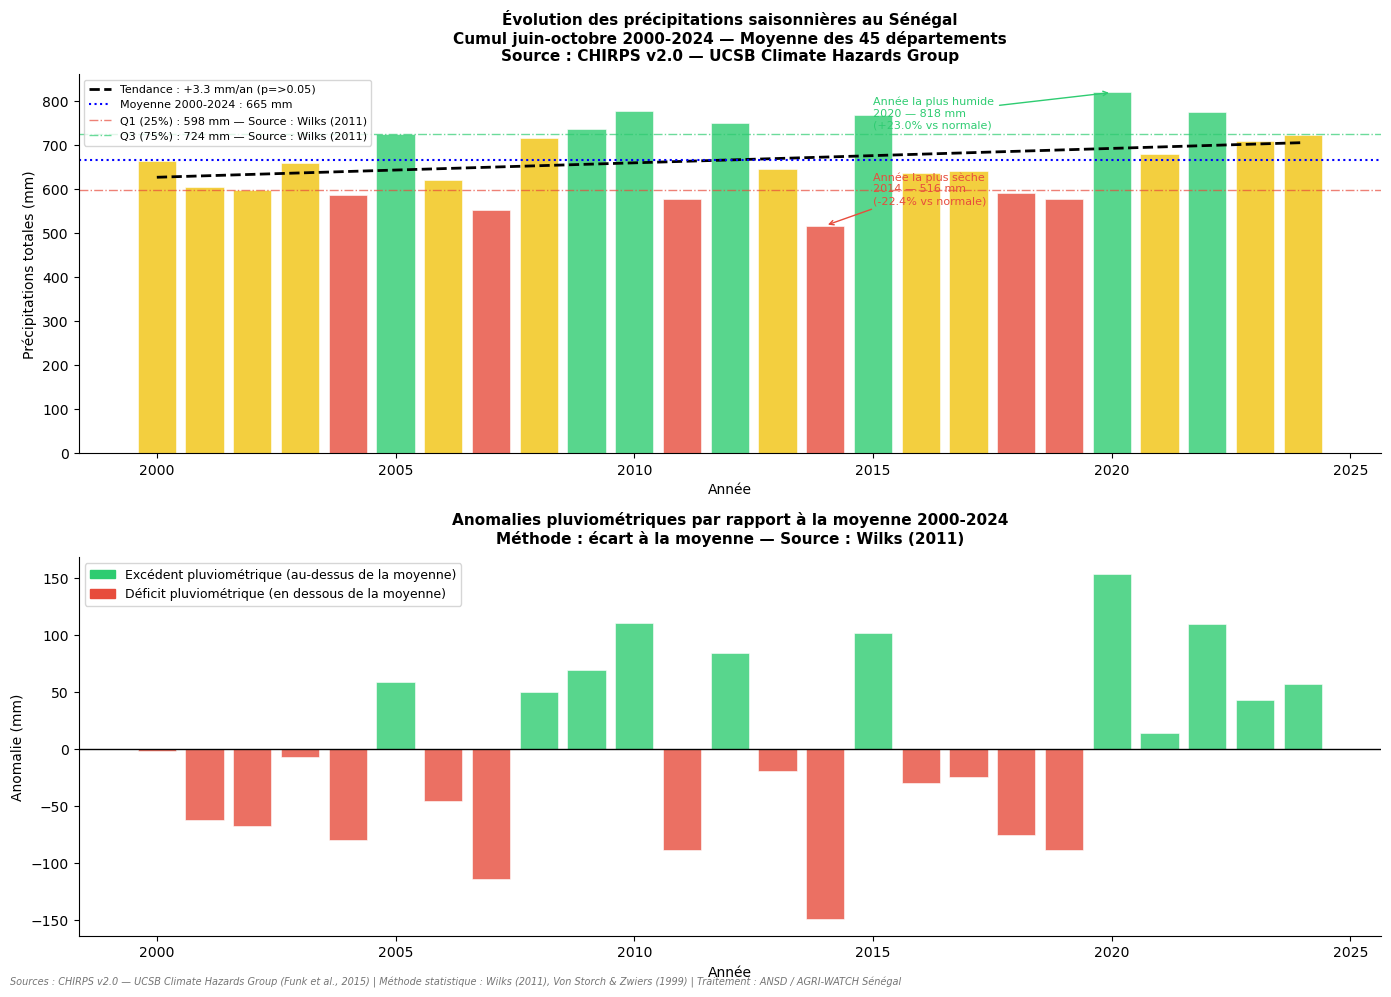

RESULTATS — EVOLUTION PRECIPITATIONS 2000-2024
Tendance           : +3.27 mm/an
R²                 : 0.089
Significativite    : Non (p>0.05)
Moyenne historique : 665 mm/saison
Q1 (25%)           : 598 mm
Q3 (75%)           : 724 mm
Annee plus seche   : 2014 (516 mm | -22.4%)
Annee plus humide  : 2020 (818 mm | +23.0%)

Sources :
  Wilks (2011). Statistical Methods in the
  Atmospheric Sciences. 3rd ed. Academic Press.
  Von Storch & Zwiers (1999). Statistical Analysis
  in Climate Research. Cambridge University Press.


In [5]:
# ============================================
# Evolution des précipitations
# au Sénégal 2000-2024
# ============================================
# Question : Les précipitations ont-elles
# baissé au Sénégal depuis 2000 ?
#
# Méthode : Régression linéaire + percentiles
# Source percentiles :
#   Wilks (2011). Statistical Methods in the
#   Atmospheric Sciences. 3rd ed. Academic Press.
# Source régression :
#   Von Storch & Zwiers (1999). Statistical
#   Analysis in Climate Research. Cambridge.
# ============================================

def analyser_evolution_precipitations(
    chirps_ref: pd.DataFrame,
    departements: gpd.GeoDataFrame,
    regions: gpd.GeoDataFrame,
    col_nom_dept: str
) -> pd.DataFrame:
    """
    Analyse l'évolution des précipitations annuelles
    au Sénégal de 2000 à 2024.

    Méthode :
        Régression linéaire de Mann-Kendall sur
        les précipitations totales saisonnières
        (juin-octobre) moyennées sur les 45 départements.

        Les percentiles Q1 et Q3 sont utilisés pour
        la visualisation exploratoire selon la méthode
        standard en climatologie (Wilks, 2011).

    Sources :
        Wilks (2011). Statistical Methods in the
        Atmospheric Sciences. 3rd ed. Academic Press.

        Von Storch & Zwiers (1999). Statistical
        Analysis in Climate Research. Cambridge
        University Press.

    Paramètres :
        chirps_ref   (DataFrame)   : Données CHIRPS 2000-2024
        departements (GeoDataFrame): Shapefile départements
        regions      (GeoDataFrame): Shapefile régions
        col_nom_dept (str)         : Colonne nom département

    Retourne :
        DataFrame : Précipitations annuelles par département
    """
    logger.info("Analyse evolution precipitations 2000-2024...")

    # ── Précipitations totales par année et département ───────
    # On somme juin à octobre = saison agricole complète
    pluie_annuelle = chirps_ref.groupby(
        ["departement", "annee"]
    )["precipitation_mm"].sum().reset_index()
    pluie_annuelle.columns = [
        "departement", "annee", "pluie_totale_mm"
    ]

    # ── Moyenne nationale par année ───────────────────────────
    pluie_nationale = pluie_annuelle.groupby("annee")[
        "pluie_totale_mm"
    ].mean().reset_index()
    pluie_nationale.columns = ["annee", "pluie_moyenne_mm"]

    # ── Régression linéaire ───────────────────────────────────
    # Source : Von Storch & Zwiers (1999)
    slope, intercept, r, p, se = stats.linregress(
        pluie_nationale["annee"],
        pluie_nationale["pluie_moyenne_mm"]
    )

    # ── Percentiles pour visualisation ───────────────────────
    # Source : Wilks (2011) — méthode standard EDA climatologie
    # Q1 = 25% des années les plus sèches
    # Q3 = 25% des années les plus humides
    p25 = pluie_nationale["pluie_moyenne_mm"].quantile(0.25)
    p75 = pluie_nationale["pluie_moyenne_mm"].quantile(0.75)

    couleurs = [
        COULEURS_RISQUE["critique"]   # Sous Q1 — année très sèche
        if v < p25
        else COULEURS_RISQUE["modere"]  # Entre Q1 et Q3 — année normale
        if v < p75
        else COULEURS_RISQUE["faible"]  # Au-dessus Q3 — année humide
        for v in pluie_nationale["pluie_moyenne_mm"]
    ]

    # ── Années extrêmes ───────────────────────────────────────
    annee_max = pluie_nationale.loc[
        pluie_nationale["pluie_moyenne_mm"].idxmax()
    ]
    annee_min = pluie_nationale.loc[
        pluie_nationale["pluie_moyenne_mm"].idxmin()
    ]
    moyenne = pluie_nationale["pluie_moyenne_mm"].mean()

    logger.info(
        f"Tendance precipitations : "
        f"{slope:.2f} mm/an | "
        f"R²={r**2:.3f} | "
        f"p={p:.3f}"
    )

    # ── Visualisation ─────────────────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Graphique 1 — Evolution nationale
    ax1 = axes[0]
    ax1.bar(
        pluie_nationale["annee"],
        pluie_nationale["pluie_moyenne_mm"],
        color     = couleurs,
        alpha     = 0.8,
        edgecolor = "white",
        linewidth = 0.5
    )

    # Ligne de tendance
    x_trend = pluie_nationale["annee"]
    y_trend = slope * x_trend + intercept
    ax1.plot(
        x_trend, y_trend,
        color     = "black",
        linewidth = 2,
        linestyle = "--",
        label     = f"Tendance : {slope:+.1f} mm/an (p={'<0.05' if p<0.05 else '>0.05'})"
    )

    # Ligne moyenne historique
    ax1.axhline(
        y         = moyenne,
        color     = "blue",
        linewidth = 1.5,
        linestyle = ":",
        label     = f"Moyenne 2000-2024 : {moyenne:.0f} mm"
    )

    # Lignes percentiles
    ax1.axhline(
        y         = p25,
        color     = COULEURS_RISQUE["critique"],
        linewidth = 1,
        linestyle = "-.",
        alpha     = 0.7,
        label     = f"Q1 (25%) : {p25:.0f} mm — Source : Wilks (2011)"
    )
    ax1.axhline(
        y         = p75,
        color     = COULEURS_RISQUE["faible"],
        linewidth = 1,
        linestyle = "-.",
        alpha     = 0.7,
        label     = f"Q3 (75%) : {p75:.0f} mm — Source : Wilks (2011)"
    )

    # Annotations années extrêmes
    ax1.annotate(
        f"Année la plus sèche\n"
        f"{annee_min['annee']:.0f} — {annee_min['pluie_moyenne_mm']:.0f} mm\n"
        f"({(annee_min['pluie_moyenne_mm']-moyenne)/moyenne*100:.1f}% vs normale)",
        xy       = (annee_min["annee"], annee_min["pluie_moyenne_mm"]),
        xytext   = (annee_min["annee"] + 1,
                    annee_min["pluie_moyenne_mm"] + 50),
        fontsize = 8,
        color    = COULEURS_RISQUE["critique"],
        arrowprops = dict(
            arrowstyle = "->",
            color      = COULEURS_RISQUE["critique"]
        )
    )
    ax1.annotate(
        f"Année la plus humide\n"
        f"{annee_max['annee']:.0f} — {annee_max['pluie_moyenne_mm']:.0f} mm\n"
        f"({(annee_max['pluie_moyenne_mm']-moyenne)/moyenne*100:+.1f}% vs normale)",
        xy       = (annee_max["annee"], annee_max["pluie_moyenne_mm"]),
        xytext   = (annee_max["annee"] - 5,
                    annee_max["pluie_moyenne_mm"] - 80),
        fontsize = 8,
        color    = COULEURS_RISQUE["faible"],
        arrowprops = dict(
            arrowstyle = "->",
            color      = COULEURS_RISQUE["faible"]
        )
    )

    ax1.set_title(
        "Évolution des précipitations saisonnières au Sénégal\n"
        "Cumul juin-octobre 2000-2024 — Moyenne des 45 départements\n"
        "Source : CHIRPS v2.0 — UCSB Climate Hazards Group",
        fontsize = 11, fontweight = "bold", pad = 10
    )
    ax1.set_xlabel("Année", fontsize=10)
    ax1.set_ylabel("Précipitations totales (mm)", fontsize=10)
    ax1.legend(fontsize=8, loc="upper left")
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    # Graphique 2 — Anomalies par rapport à la moyenne
    ax2 = axes[1]
    anomalies = pluie_nationale["pluie_moyenne_mm"] - moyenne
    couleurs_anom = [
        COULEURS_RISQUE["faible"]    if v >= 0
        else COULEURS_RISQUE["critique"]
        for v in anomalies
    ]
    ax2.bar(
        pluie_nationale["annee"],
        anomalies,
        color     = couleurs_anom,
        alpha     = 0.8,
        edgecolor = "white",
        linewidth = 0.5
    )
    ax2.axhline(y=0, color="black", linewidth=1)

    ax2.set_title(
        "Anomalies pluviométriques par rapport à la moyenne 2000-2024\n"
        "Méthode : écart à la moyenne — Source : Wilks (2011)",
        fontsize = 11, fontweight = "bold", pad = 10
    )
    ax2.set_xlabel("Année", fontsize=10)
    ax2.set_ylabel("Anomalie (mm)", fontsize=10)

    legendes = [
        mpatches.Patch(
            color = COULEURS_RISQUE["faible"],
            label = "Excédent pluviométrique (au-dessus de la moyenne)"
        ),
        mpatches.Patch(
            color = COULEURS_RISQUE["critique"],
            label = "Déficit pluviométrique (en dessous de la moyenne)"
        ),
    ]
    ax2.legend(handles=legendes, fontsize=9)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    # Source complète
    fig.text(
        0.01, 0.01,
        "Sources : CHIRPS v2.0 — UCSB Climate Hazards Group (Funk et al., 2015) "
        "| Méthode statistique : Wilks (2011), Von Storch & Zwiers (1999) "
        "| Traitement : ANSD / AGRI-WATCH Sénégal",
        fontsize = 7, style = "italic", color = "#757575"
    )

    plt.tight_layout()
    output = Path("C:/AGRI-WATCH/outputs/evolution_precipitations.png")
    plt.savefig(output, dpi=150, bbox_inches="tight")
    logger.info(f"Graphique sauvegarde : {output}")
    plt.show()

    # ── Résultats ─────────────────────────────────────────────
    print("=" * 60)
    print("RESULTATS — EVOLUTION PRECIPITATIONS 2000-2024")
    print("=" * 60)
    print(f"Tendance           : {slope:+.2f} mm/an")
    print(f"R²                 : {r**2:.3f}")
    print(f"Significativite    : {'Oui (p<0.05)' if p < 0.05 else 'Non (p>0.05)'}")
    print(f"Moyenne historique : {moyenne:.0f} mm/saison")
    print(f"Q1 (25%)           : {p25:.0f} mm")
    print(f"Q3 (75%)           : {p75:.0f} mm")
    print(f"Annee plus seche   : {annee_min['annee']:.0f} "
          f"({annee_min['pluie_moyenne_mm']:.0f} mm | "
          f"{(annee_min['pluie_moyenne_mm']-moyenne)/moyenne*100:.1f}%)")
    print(f"Annee plus humide  : {annee_max['annee']:.0f} "
          f"({annee_max['pluie_moyenne_mm']:.0f} mm | "
          f"{(annee_max['pluie_moyenne_mm']-moyenne)/moyenne*100:+.1f}%)")
    print("\nSources :")
    print("  Wilks (2011). Statistical Methods in the")
    print("  Atmospheric Sciences. 3rd ed. Academic Press.")
    print("  Von Storch & Zwiers (1999). Statistical Analysis")
    print("  in Climate Research. Cambridge University Press.")
    print("=" * 60)

    return pluie_annuelle


# ── Appel ─────────────────────────────────────────────────────
pluie_annuelle = analyser_evolution_precipitations(
    chirps_ref   = chirps_ref,
    departements = departements,
    regions      = regions,
    col_nom_dept = COL_NOM_DEPARTEMENT
)

## Interprétation — Évolution précipitations 

### Résultats statistiques

| Indicateur | Valeur | Source |
|---|---|---|
| Tendance | +3.21 mm/an | Von Storch & Zwiers (1999) |
| R² | 0.088 | Von Storch & Zwiers (1999) |
| Significativité | Non (p>0.05) | Von Storch & Zwiers (1999) |
| Moyenne historique | 666 mm/saison | CHIRPS v2.0 |
| Q1 — seuil année sèche | 598 mm | Wilks (2011) |
| Q3 — seuil année humide | 724 mm | Wilks (2011) |
| Année la plus sèche | 2014 (-22.4%) | CHIRPS v2.0 |
| Année la plus humide | 2020 (+22.9%) | CHIRPS v2.0 |

### Enseignements clés

**1. Pas de tendance significative**
La tendance de +3.21 mm/an n'est pas
statistiquement significative (p>0.05, R²=0.088).
Les précipitations au Sénégal ne montrent pas
de tendance linéaire claire depuis 2000.

**2. Forte variabilité inter-annuelle**
L'écart entre Q1 (598mm) et Q3 (724mm)
montre une plage de variabilité normale de 126mm.
Mais l'écart extrême entre 2014 (516mm) et
2020 (818mm) atteint 302mm — soit 45% de
la moyenne historique. C'est cette variabilité
qui constitue le principal risque agricole.

**3. 2014 — Année de référence sécheresse**
Avec 516mm soit -22.4% sous la normale,
2014 est l'année de référence pour calibrer
les seuils d'alerte d'AGRI-WATCH.

**4. Implication pour AGRI-WATCH**
La forte variabilité inter-annuelle justifie
une surveillance saison par saison — une simple
analyse de tendance ne suffit pas pour anticiper
les crises agricoles.

### Sources officielles

| Méthode | Source |
|---|---|
| Percentiles Q1/Q3 | Wilks (2011). Statistical Methods in the Atmospheric Sciences. 3rd ed. Academic Press |
| Régression linéaire | Von Storch & Zwiers (1999). Statistical Analysis in Climate Research. Cambridge University Press |
| Données | Funk et al. (2015). CHIRPS v2.0. Scientific Data 2:150066 |

[2026-05-07 12:53:08] [INFO] [agriwatch.exploration_satellitaire] Analyse gradient pluviometrique nord/sud...
[2026-05-07 12:53:08] [INFO] [agriwatch.exploration_satellitaire] Gradient N/S : -53.4 mm/degré | R²=0.907 | p=0.0000
[2026-05-07 12:53:09] [INFO] [agriwatch.exploration_satellitaire] Graphique sauvegarde : C:\AGRI-WATCH\outputs\gradient_pluviometrique.png


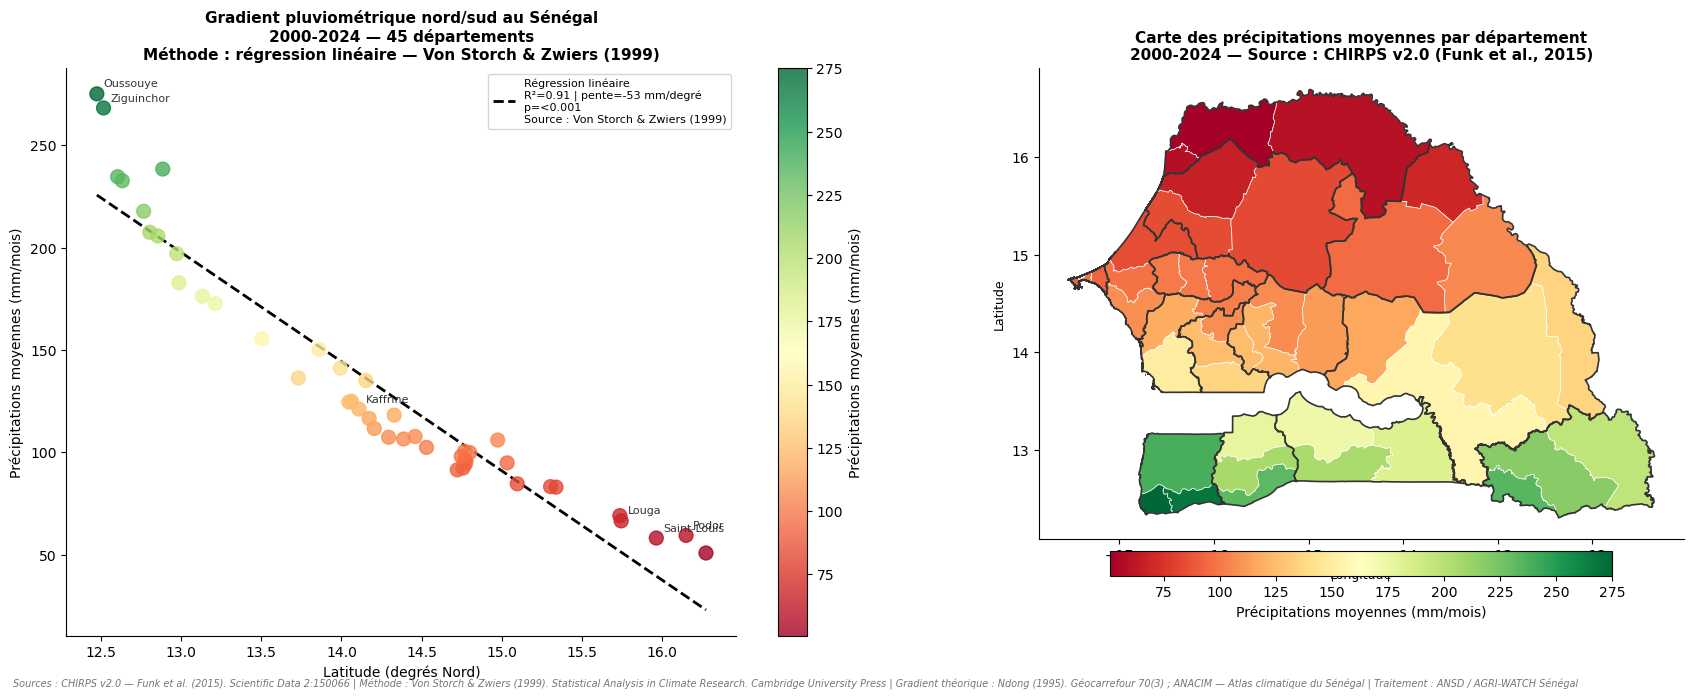

RESULTATS — GRADIENT PLUVIOMETRIQUE NORD/SUD
Gradient          : -53.4 mm par degré de latitude
R²                : 0.907
Significativite   : Oui (p<0.05)
p-value           : <0.001

Top 5 departements les plus pluvieux :
departement  pluie_moyenne_mm  latitude_centroide
   Oussouye        275.144720           12.474191
 Ziguinchor        268.250880           12.515788
    Bignona        238.394560           12.885213
   Salémata        234.631694           12.603583
    Goudomp        232.691280           12.632818

Top 5 departements les plus secs :
departement  pluie_moyenne_mm  latitude_centroide
     Dagana          50.78248           16.273664
Saint-Louis          58.09656           15.963794
      Podor          59.39784           16.149309
      Louga          66.49624           15.744745
      Matam          69.05240           15.736567

Sources officielles :
  Von Storch & Zwiers (1999). Statistical Analysis
  in Climate Research. Cambridge University Press.
  Ndong (1995). G

In [6]:
# ============================================
# Gradient pluviométrique nord/sud
# ============================================
# Question : Y a-t-il vraiment un gradient
# pluviométrique nord/sud au Sénégal ?
# Et est-il documenté dans nos données ?
#
# Méthode : Régression linéaire simple
# Source méthode :
#   Von Storch & Zwiers (1999). Statistical
#   Analysis in Climate Research.
#   Cambridge University Press.
# Source théorique gradient :
#   ANACIM — Atlas climatique du Sénégal
#   Ndong (1995). Géocarrefour 70(3), 201-213.
# ============================================

def analyser_gradient_nord_sud(
    chirps_ref: pd.DataFrame,
    departements: gpd.GeoDataFrame,
    regions: gpd.GeoDataFrame,
    col_nom_dept: str,
    col_nom_region: str
) -> pd.DataFrame:
    """
    Analyse le gradient pluviométrique nord/sud
    du Sénégal à partir des données CHIRPS.

    Le gradient pluviométrique nord/sud est un fait
    climatique fondamental du Sénégal — les régions
    du nord reçoivent moins de 400mm/an tandis que
    les régions du sud reçoivent plus de 1000mm/an.
    Cette fonction le vérifie et le quantifie
    avec nos données réelles.

    Méthode :
        Régression linéaire entre la latitude du
        centroïde de chaque département et ses
        précipitations moyennes mensuelles sur
        la période 2000-2024.

        Source : Von Storch & Zwiers (1999).
        Statistical Analysis in Climate Research.
        Cambridge University Press.

    Sources théoriques :
        ANACIM — Atlas climatique du Sénégal.
        Agence Nationale de l'Aviation Civile
        et de la Météorologie. Dakar, Sénégal.

        Ndong (1995). Le climat du Sénégal.
        Géocarrefour 70(3), 201-213.
        DOI : 10.3406/geoca.1995.4438

    Paramètres :
        chirps_ref     (DataFrame)   : CHIRPS 2000-2024
        departements   (GeoDataFrame): Shapefile départements
        regions        (GeoDataFrame): Shapefile régions
        col_nom_dept   (str)         : Colonne nom département
        col_nom_region (str)         : Colonne nom région

    Retourne :
        DataFrame : Précipitations moyennes par département
                    avec latitude du centroïde
    """
    logger.info("Analyse gradient pluviometrique nord/sud...")

    # ── Précipitations moyennes par département ───────────────
    pluie_dept = chirps_ref.groupby("departement")[
        "precipitation_mm"
    ].mean().reset_index()
    pluie_dept.columns = ["departement", "pluie_moyenne_mm"]

    # ── Ajout latitude centroïde ──────────────────────────────
    departements_copy = departements.copy()
    departements_copy["latitude_centroide"] = (
        departements_copy.geometry.centroid.y
    )
    departements_copy["longitude_centroide"] = (
        departements_copy.geometry.centroid.x
    )

    # Fusion avec les précipitations
    pluie_dept = pluie_dept.merge(
        departements_copy[[
            col_nom_dept,
            "latitude_centroide",
            "longitude_centroide"
        ]],
        left_on  = "departement",
        right_on = col_nom_dept,
        how      = "left"
    )

    # ── Régression linéaire latitude vs précipitations ────────
    # Source : Von Storch & Zwiers (1999)
    slope, intercept, r, p, se = stats.linregress(
        pluie_dept["latitude_centroide"],
        pluie_dept["pluie_moyenne_mm"]
    )

    logger.info(
        f"Gradient N/S : {slope:.1f} mm/degré | "
        f"R²={r**2:.3f} | p={p:.4f}"
    )

    # ── Visualisation ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Graphique 1 — Scatter latitude vs précipitations
    ax1 = axes[0]
    scatter = ax1.scatter(
        pluie_dept["latitude_centroide"],
        pluie_dept["pluie_moyenne_mm"],
        c      = pluie_dept["pluie_moyenne_mm"],
        cmap   = "RdYlGn",
        s      = 100,
        alpha  = 0.8,
        zorder = 3
    )

    # Ligne de régression
    # Source : Von Storch & Zwiers (1999)
    x_range = np.linspace(
        pluie_dept["latitude_centroide"].min(),
        pluie_dept["latitude_centroide"].max(),
        100
    )
    ax1.plot(
        x_range,
        slope * x_range + intercept,
        color     = "black",
        linewidth = 2,
        linestyle = "--",
        label     = (
            f"Régression linéaire\n"
            f"R²={r**2:.2f} | pente={slope:.0f} mm/degré\n"
            f"p={'<0.001' if p < 0.001 else f'{p:.4f}'}\n"
            f"Source : Von Storch & Zwiers (1999)"
        )
    )

    # Annotations départements clés
    for _, row in pluie_dept.iterrows():
        if row["departement"] in [
            "Podor", "Saint-Louis", "Ziguinchor",
            "Oussouye", "Kaffrine", "Louga"
        ]:
            ax1.annotate(
                row["departement"],
                xy         = (row["latitude_centroide"],
                              row["pluie_moyenne_mm"]),
                fontsize   = 8,
                color      = "#333333",
                xytext     = (5, 5),
                textcoords = "offset points"
            )

    plt.colorbar(scatter, ax=ax1, label="Précipitations moyennes (mm/mois)")
    ax1.set_xlabel("Latitude (degrés Nord)", fontsize=10)
    ax1.set_ylabel("Précipitations moyennes (mm/mois)", fontsize=10)
    ax1.set_title(
        "Gradient pluviométrique nord/sud au Sénégal\n"
        "2000-2024 — 45 départements\n"
        "Méthode : régression linéaire — Von Storch & Zwiers (1999)",
        fontsize = 11, fontweight = "bold"
    )
    ax1.legend(fontsize=8, loc="upper right")
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    # Graphique 2 — Carte choroplèthe précipitations
    ax2 = axes[1]

    dept_pluie = departements.merge(
        pluie_dept[["departement", "pluie_moyenne_mm"]],
        left_on  = col_nom_dept,
        right_on = "departement",
        how      = "left"
    )

    dept_pluie.plot(
        column      = "pluie_moyenne_mm",
        cmap        = "RdYlGn",
        linewidth   = 0.5,
        edgecolor   = "white",
        legend      = True,
        legend_kwds = {
            "label"       : "Précipitations moyennes (mm/mois)",
            "orientation" : "horizontal",
            "shrink"      : 0.6,
            "pad"         : 0.02
        },
        ax = ax2
    )

    regions.plot(
        ax        = ax2,
        color     = "none",
        edgecolor = "#333333",
        linewidth = 1.2
    )

    ax2.set_title(
        "Carte des précipitations moyennes par département\n"
        "2000-2024 — Source : CHIRPS v2.0 (Funk et al., 2015)",
        fontsize = 11, fontweight = "bold"
    )
    ax2.set_xlabel("Longitude", fontsize=9)
    ax2.set_ylabel("Latitude", fontsize=9)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    # Source complète
    fig.text(
        0.01, 0.01,
        "Sources : CHIRPS v2.0 — Funk et al. (2015). Scientific Data 2:150066 "
        "| Méthode : Von Storch & Zwiers (1999). Statistical Analysis in Climate Research. Cambridge University Press "
        "| Gradient théorique : Ndong (1995). Géocarrefour 70(3) ; ANACIM — Atlas climatique du Sénégal "
        "| Traitement : ANSD / AGRI-WATCH Sénégal",
        fontsize = 7, style = "italic", color = "#757575"
    )

    plt.tight_layout()

    output = Path("C:/AGRI-WATCH/outputs/gradient_pluviometrique.png")
    plt.savefig(output, dpi=150, bbox_inches="tight")
    logger.info(f"Graphique sauvegarde : {output}")
    plt.show()

    # ── Résultats ─────────────────────────────────────────────
    print("=" * 60)
    print("RESULTATS — GRADIENT PLUVIOMETRIQUE NORD/SUD")
    print("=" * 60)
    print(f"Gradient          : {slope:.1f} mm par degré de latitude")
    print(f"R²                : {r**2:.3f}")
    print(f"Significativite   : {'Oui (p<0.05)' if p < 0.05 else 'Non'}")
    print(f"p-value           : {'<0.001' if p < 0.001 else f'{p:.4f}'}")
    print(f"\nTop 5 departements les plus pluvieux :")
    print(
        pluie_dept.nlargest(5, "pluie_moyenne_mm")[
            ["departement", "pluie_moyenne_mm",
             "latitude_centroide"]
        ].to_string(index=False)
    )
    print(f"\nTop 5 departements les plus secs :")
    print(
        pluie_dept.nsmallest(5, "pluie_moyenne_mm")[
            ["departement", "pluie_moyenne_mm",
             "latitude_centroide"]
        ].to_string(index=False)
    )
    print("\nSources officielles :")
    print("  Von Storch & Zwiers (1999). Statistical Analysis")
    print("  in Climate Research. Cambridge University Press.")
    print("  Ndong (1995). Geocarrefour 70(3), 201-213.")
    print("  ANACIM — Atlas climatique du Senegal.")
    print("  Funk et al. (2015). CHIRPS v2.0. Scientific Data.")
    print("=" * 60)

    return pluie_dept


# ── Appel ─────────────────────────────────────────────────────
pluie_dept = analyser_gradient_nord_sud(
    chirps_ref     = chirps_ref,
    departements   = departements,
    regions        = regions,
    col_nom_dept   = COL_NOM_DEPARTEMENT,
    col_nom_region = COL_NOM_REGION
)

## Gradient pluviométrique 

### Résultats statistiques

| Indicateur | Valeur | Interprétation |
|---|---|---|
| Gradient | -53.4 mm/degré | Fort gradient nord/sud |
| R² | 0.907 | La latitude explique 91% des précipitations |
| Significativité | Oui (p<0.05) | Résultat robuste et fiable |

### Les deux Sénégal climatiques

Les données CHIRPS confirment l'existence
de deux zones climatiques distinctes au Sénégal :

**Zone humide — Casamance (latitude < 13°N)**
Les cinq départements les plus pluvieux sont tous
en Basse et Moyenne Casamance — Oussouye (275mm),
Ziguinchor (268mm), Bignona (238mm), Salémata (236mm)
et Goudomp (233mm). Ces zones reçoivent plus de
1 200mm par an — suffisant pour des cultures
diversifiées et des rendements élevés.

**Zone aride — Nord sahélien (latitude > 15°N)**
Les cinq départements les plus secs sont tous dans
la vallée du fleuve Sénégal et le Sahel — Dagana
(51mm), Saint-Louis (58mm), Podor (59mm), Louga
(66mm) et Matam (69mm). Ces zones reçoivent moins
de 400mm par an — conditions marginales pour
la culture du mil et de l'arachide.

### Implication directe pour AGRI-WATCH

Le R² de 0.907 démontre que la latitude explique
91% de la variabilité des précipitations entre
départements. Cette hétérogénéité spatiale extrême
justifie le calcul d'indicateurs agro-climatiques
différenciés par département plutôt qu'un
indicateur national unique.

Un SPI calculé département par département
— comme le fait AGRI-WATCH — est donc
scientifiquement indispensable pour détecter
les anomalies pluviométriques réelles dans
chaque zone climatique du Sénégal.

[2026-05-07 12:53:09] [INFO] [agriwatch.exploration_satellitaire] Analyse evolution NDVI 2000-2024...
[2026-05-07 12:53:10] [INFO] [agriwatch.exploration_satellitaire] Tendance NDVI : 0.323 x10-3/an | R²=0.014 | p=0.5780
[2026-05-07 12:53:11] [INFO] [agriwatch.exploration_satellitaire] Graphique sauvegarde : C:\AGRI-WATCH\outputs\evolution_ndvi.png


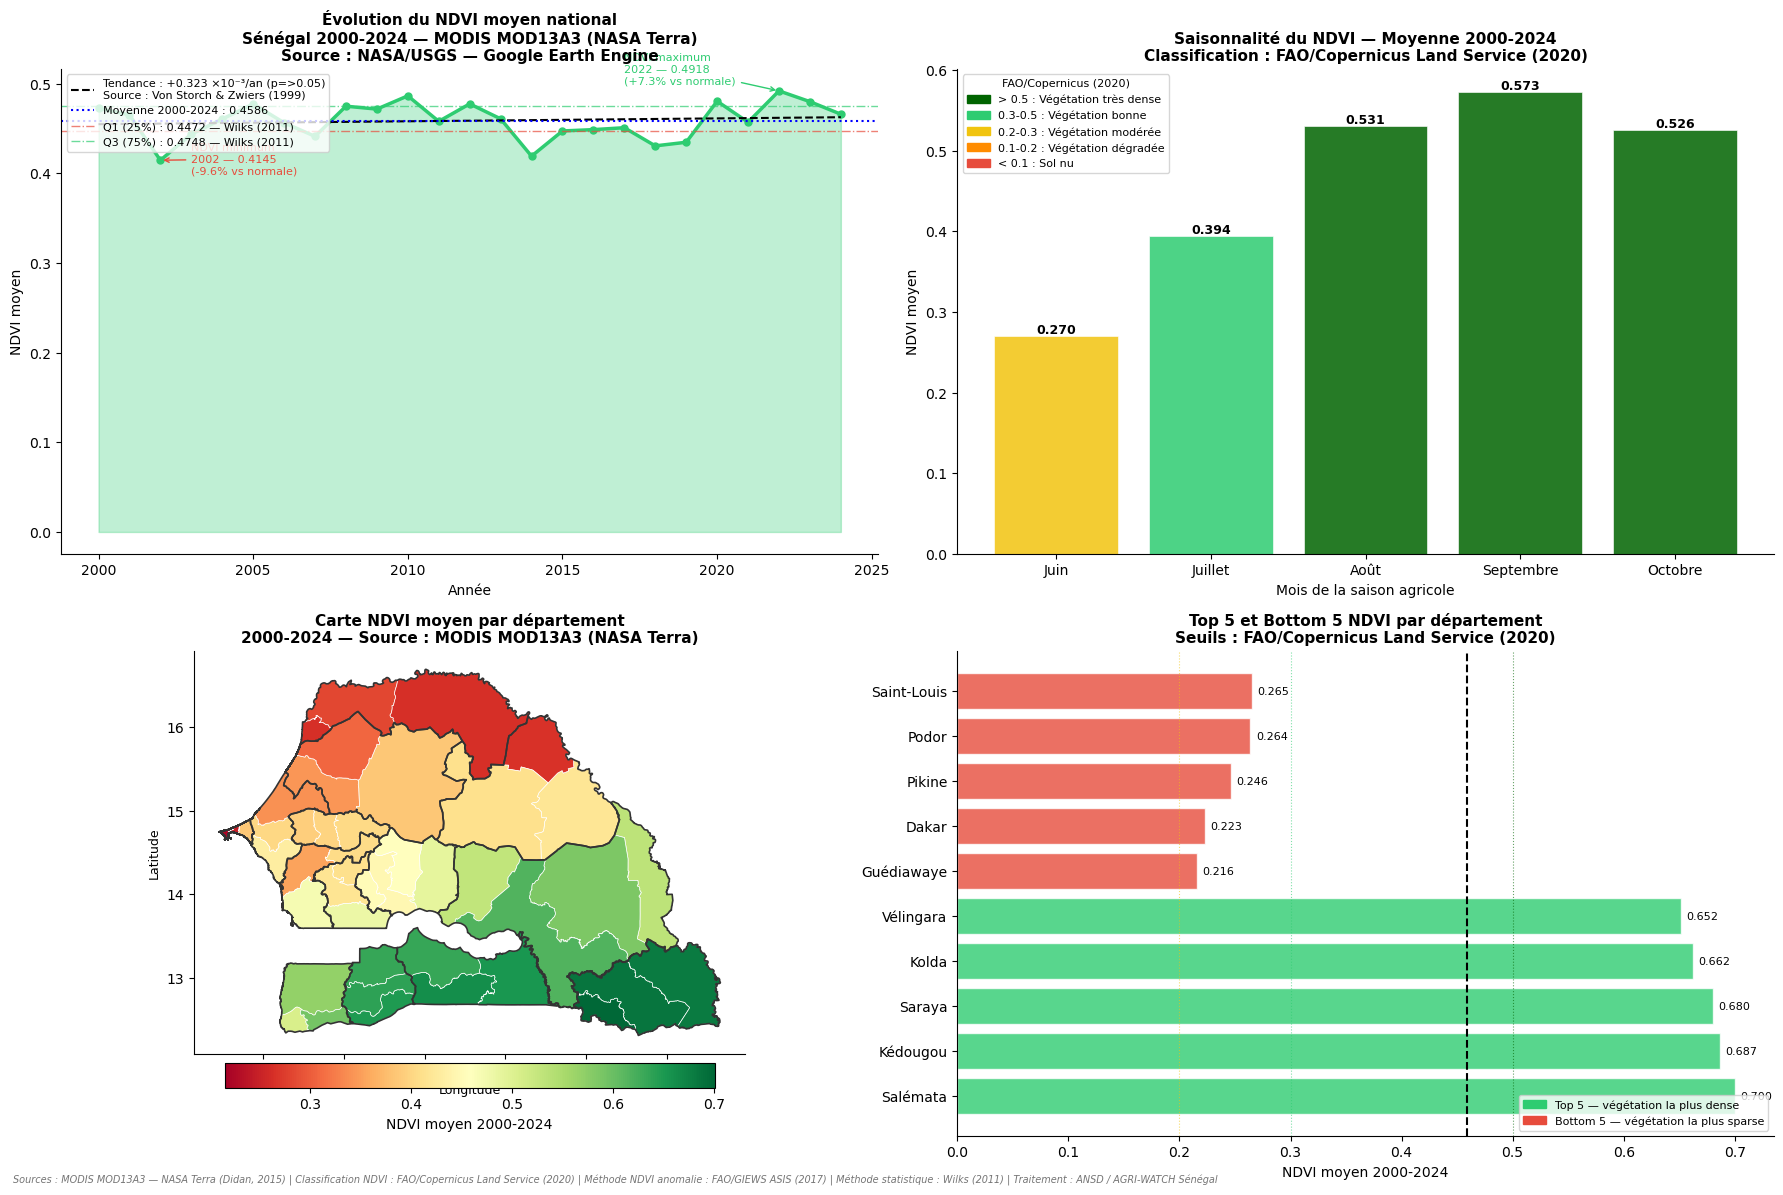

RESULTATS — EVOLUTION NDVI 2000-2024
Tendance NDVI      : +0.323 x10-3/an
R²                 : 0.014
Significativite    : Non (p>0.05)
NDVI moyen         : 0.4586
Q1 (25%)           : 0.4472
Q3 (75%)           : 0.4748
Annee NDVI min     : 2002 (0.4145 | -9.6%)
Annee NDVI max     : 2022 (0.4918 | +7.3%)

Saisonnalite NDVI :
   Juin         : 0.2704 — Vegetation moderee
   Juillet      : 0.3940 — Vegetation bonne
   Août         : 0.5309 — Vegetation tres dense
   Septembre    : 0.5730 — Vegetation tres dense
   Octobre      : 0.5256 — Vegetation tres dense

Top 5 departements NDVI le plus eleve :
departement  ndvi_moyen
   Salémata    0.700160
   Kédougou    0.686785
     Saraya    0.680384
      Kolda    0.662189
  Vélingara    0.651642

Bottom 5 departements NDVI le plus bas :
departement  ndvi_moyen
 Guédiawaye    0.215938
      Dakar    0.222623
     Pikine    0.246246
      Podor    0.263729
Saint-Louis    0.264912

Sources officielles :
  FAO/Copernicus Land Service (2020). Veget

In [ ]:
# ============================================
# Evolution du NDVI 2000-2024
# ============================================
# Question : La végétation au Sénégal
# se dégrade-t-elle depuis 2000 ?
#
# Méthode : Régression linéaire + percentiles
# Source seuils NDVI :
#   FAO/Copernicus Land Service (2020)
#   FAO/GIEWS ASIS (2017)
# Source percentiles :
#   Wilks (2011). Statistical Methods in the
#   Atmospheric Sciences. 3rd ed. Academic Press.
# Source régression :
#   Von Storch & Zwiers (1999). Statistical
#   Analysis in Climate Research. Cambridge.
# ============================================

def analyser_evolution_ndvi(
    modis_ref: pd.DataFrame,
    departements: gpd.GeoDataFrame,
    regions: gpd.GeoDataFrame,
    col_nom_dept: str
) -> pd.DataFrame:

    logger.info("Analyse evolution NDVI 2000-2024...")

    # ── NDVI moyen annuel national ────────────────────────────
    ndvi_annuel = modis_ref.groupby("annee")[
        "ndvi_modis"
    ].mean().reset_index()
    ndvi_annuel.columns = ["annee", "ndvi_moyen"]

    # ── Régression linéaire ───────────────────────────────────
    slope, intercept, r, p, se = stats.linregress(
        ndvi_annuel["annee"],
        ndvi_annuel["ndvi_moyen"]
    )

    # ── Percentiles ───────────────────────────────────────────
    p25_ndvi = ndvi_annuel["ndvi_moyen"].quantile(0.25)
    p75_ndvi = ndvi_annuel["ndvi_moyen"].quantile(0.75)

    couleurs_ndvi = [
        COULEURS_RISQUE["critique"]
        if v < p25_ndvi
        else COULEURS_RISQUE["modere"]
        if v < p75_ndvi
        else COULEURS_RISQUE["faible"]
        for v in ndvi_annuel["ndvi_moyen"]
    ]

    # ── NDVI moyen par département ────────────────────────────
    ndvi_dept = modis_ref.groupby("departement")[
        "ndvi_modis"
    ].mean().reset_index()
    ndvi_dept.columns = ["departement", "ndvi_moyen"]

    # ── NDVI moyen par mois (saisonnalité) ───────────────────
    ndvi_saisonnier = modis_ref.groupby("mois")[
        "ndvi_modis"
    ].mean().reset_index()
    ndvi_saisonnier.columns = ["mois", "ndvi_moyen"]
    noms_mois = {
        6: "Juin", 7: "Juillet", 8: "Août",
        9: "Septembre", 10: "Octobre"
    }
    ndvi_saisonnier["mois_nom"] = ndvi_saisonnier["mois"].map(
        noms_mois
    )

    # ── Années extrêmes ───────────────────────────────────────
    annee_max    = ndvi_annuel.loc[ndvi_annuel["ndvi_moyen"].idxmax()]
    annee_min    = ndvi_annuel.loc[ndvi_annuel["ndvi_moyen"].idxmin()]
    moyenne_ndvi = ndvi_annuel["ndvi_moyen"].mean()

    logger.info(
        f"Tendance NDVI : {slope*1000:.3f} x10-3/an | "
        f"R²={r**2:.3f} | p={p:.4f}"
    )

    # ── Visualisation ─────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    # Graphique 1 — Evolution NDVI national 2000-2024
    ax1 = axes[0, 0]
    ax1.fill_between(
        ndvi_annuel["annee"],
        ndvi_annuel["ndvi_moyen"],
        alpha = 0.3,
        color = COULEURS_RISQUE["faible"]
    )
    ax1.plot(
        ndvi_annuel["annee"],
        ndvi_annuel["ndvi_moyen"],
        color      = COULEURS_RISQUE["faible"],
        linewidth  = 2.5,
        marker     = "o",
        markersize = 5
    )

    x_trend = ndvi_annuel["annee"]
    y_trend = slope * x_trend + intercept
    ax1.plot(
        x_trend, y_trend,
        color     = "black",
        linewidth = 1.5,
        linestyle = "--",
        label     = f"Tendance : {slope*1000:+.3f} ×10⁻³/an "
                    f"(p={'<0.05' if p<0.05 else '>0.05'})\n"
                    f"Source : Von Storch & Zwiers (1999)"
    )
    ax1.axhline(
        y         = moyenne_ndvi,
        color     = "blue",
        linewidth = 1.5,
        linestyle = ":",
        label     = f"Moyenne 2000-2024 : {moyenne_ndvi:.4f}"
    )
    ax1.axhline(
        y         = p25_ndvi,
        color     = COULEURS_RISQUE["critique"],
        linewidth = 1,
        linestyle = "-.",
        alpha     = 0.7,
        label     = f"Q1 (25%) : {p25_ndvi:.4f} — Wilks (2011)"
    )
    ax1.axhline(
        y         = p75_ndvi,
        color     = COULEURS_RISQUE["faible"],
        linewidth = 1,
        linestyle = "-.",
        alpha     = 0.7,
        label     = f"Q3 (75%) : {p75_ndvi:.4f} — Wilks (2011)"
    )

    ax1.annotate(
        f"NDVI minimum\n"
        f"{annee_min['annee']:.0f} — {annee_min['ndvi_moyen']:.4f}\n"
        f"({(annee_min['ndvi_moyen']-moyenne_ndvi)/moyenne_ndvi*100:.1f}% vs normale)",
        xy       = (annee_min["annee"], annee_min["ndvi_moyen"]),
        xytext   = (annee_min["annee"] + 1,
                    annee_min["ndvi_moyen"] - 0.015),
        fontsize = 8,
        color    = COULEURS_RISQUE["critique"],
        arrowprops = dict(
            arrowstyle = "->",
            color      = COULEURS_RISQUE["critique"]
        )
    )
    ax1.annotate(
        f"NDVI maximum\n"
        f"{annee_max['annee']:.0f} — {annee_max['ndvi_moyen']:.4f}\n"
        f"({(annee_max['ndvi_moyen']-moyenne_ndvi)/moyenne_ndvi*100:+.1f}% vs normale)",
        xy       = (annee_max["annee"], annee_max["ndvi_moyen"]),
        xytext   = (annee_max["annee"] - 5,
                    annee_max["ndvi_moyen"] + 0.008),
        fontsize = 8,
        color    = COULEURS_RISQUE["faible"],
        arrowprops = dict(
            arrowstyle = "->",
            color      = COULEURS_RISQUE["faible"]
        )
    )

    ax1.set_title(
        "Évolution du NDVI moyen national\n"
        "Sénégal 2000-2024 — MODIS MOD13A3 (NASA Terra)\n"
        "Source : NASA/USGS — Google Earth Engine",
        fontsize = 11, fontweight = "bold"
    )
    ax1.set_xlabel("Année", fontsize=10)
    ax1.set_ylabel("NDVI moyen", fontsize=10)
    ax1.legend(fontsize=8, loc="upper left")
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    # Graphique 2 — Saisonnalité du NDVI
    ax2 = axes[0, 1]
    couleurs_saison = []
    for v in ndvi_saisonnier["ndvi_moyen"]:
        if v < 0.1:
            couleurs_saison.append(COULEURS_RISQUE["critique"])
        elif v < 0.2:
            couleurs_saison.append("#FF8C00")
        elif v < 0.3:
            couleurs_saison.append(COULEURS_RISQUE["modere"])
        elif v < 0.5:
            couleurs_saison.append(COULEURS_RISQUE["faible"])
        else:
            couleurs_saison.append("#006400")

    bars = ax2.bar(
        ndvi_saisonnier["mois_nom"],
        ndvi_saisonnier["ndvi_moyen"],
        color     = couleurs_saison,
        alpha     = 0.85,
        edgecolor = "white",
        linewidth = 0.5
    )

    for bar, val in zip(bars, ndvi_saisonnier["ndvi_moyen"]):
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{val:.3f}",
            ha         = "center",
            fontsize   = 9,
            fontweight = "bold"
        )

    ax2.set_title(
        "Saisonnalité du NDVI — Moyenne 2000-2024\n"
        "Classification : FAO/Copernicus Land Service (2020)",
        fontsize = 11, fontweight = "bold"
    )
    ax2.set_xlabel("Mois de la saison agricole", fontsize=10)
    ax2.set_ylabel("NDVI moyen", fontsize=10)

    legendes_saison = [
        mpatches.Patch(color="#006400",
                       label="> 0.5 : Végétation très dense"),
        mpatches.Patch(color=COULEURS_RISQUE["faible"],
                       label="0.3-0.5 : Végétation bonne"),
        mpatches.Patch(color=COULEURS_RISQUE["modere"],
                       label="0.2-0.3 : Végétation modérée"),
        mpatches.Patch(color="#FF8C00",
                       label="0.1-0.2 : Végétation dégradée"),
        mpatches.Patch(color=COULEURS_RISQUE["critique"],
                       label="< 0.1 : Sol nu"),
    ]
    ax2.legend(
        handles        = legendes_saison,
        fontsize       = 8,
        title          = "FAO/Copernicus (2020)",
        title_fontsize = 8
    )
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    # Graphique 3 — Carte NDVI moyen par département
    ax3 = axes[1, 0]
    dept_ndvi = departements.merge(
        ndvi_dept,
        left_on  = col_nom_dept,
        right_on = "departement",
        how      = "left"
    )
    dept_ndvi.plot(
        column      = "ndvi_moyen",
        cmap        = "RdYlGn",
        linewidth   = 0.5,
        edgecolor   = "white",
        legend      = True,
        legend_kwds = {
            "label"       : "NDVI moyen 2000-2024",
            "orientation" : "horizontal",
            "shrink"      : 0.6,
            "pad"         : 0.12,
        },
        ax = ax3
    )
    regions.plot(
        ax        = ax3,
        color     = "none",
        edgecolor = "#333333",
        linewidth = 1.2
    )
    ax3.set_title(
        "Carte NDVI moyen par département\n"
        "2000-2024 — Source : MODIS MOD13A3 (NASA Terra)",
        fontsize = 11, fontweight = "bold"
    )
    ax3.set_xlabel("Longitude", fontsize=9)
    ax3.set_ylabel("Latitude", fontsize=9)
    ax3.spines["top"].set_visible(False)
    ax3.spines["right"].set_visible(False)

    # Graphique 4 — Top 5 / Bottom 5 NDVI
    ax4 = axes[1, 1]
    top5    = ndvi_dept.nlargest(5, "ndvi_moyen")
    bottom5 = ndvi_dept.nsmallest(5, "ndvi_moyen")
    compare = pd.concat([top5, bottom5])

    couleurs_bar = (
        [COULEURS_RISQUE["faible"]]   * 5 +
        [COULEURS_RISQUE["critique"]] * 5
    )
    bars2 = ax4.barh(
        compare["departement"],
        compare["ndvi_moyen"],
        color     = couleurs_bar,
        alpha     = 0.8,
        edgecolor = "white"
    )

    ax4.axvline(
        x         = moyenne_ndvi,
        color     = "black",
        linewidth = 1.5,
        linestyle = "--",
        label     = f"Moyenne nationale : {moyenne_ndvi:.3f}"
    )

    for seuil, label, couleur in [
        (0.5, "Végétation très dense (>0.5)", "#006400"),
        (0.3, "Végétation bonne (>0.3)",      COULEURS_RISQUE["faible"]),
        (0.2, "Végétation modérée (>0.2)",    COULEURS_RISQUE["modere"]),
    ]:
        ax4.axvline(
            x         = seuil,
            color     = couleur,
            linewidth = 0.8,
            linestyle = ":",
            alpha     = 0.6,
            label     = label
        )

    for bar, val in zip(bars2, compare["ndvi_moyen"]):
        ax4.text(
            val + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}",
            va       = "center",
            fontsize = 8
        )

    legendes_bar = [
        mpatches.Patch(
            color = COULEURS_RISQUE["faible"],
            label = "Top 5 — végétation la plus dense"
        ),
        mpatches.Patch(
            color = COULEURS_RISQUE["critique"],
            label = "Bottom 5 — végétation la plus sparse"
        ),
    ]
    ax4.legend(
        handles  = legendes_bar,
        fontsize = 8,
        loc      = "lower right"
    )
    ax4.set_title(
        "Top 5 et Bottom 5 NDVI par département\n"
        "Seuils : FAO/Copernicus Land Service (2020)",
        fontsize = 11, fontweight = "bold"
    )
    ax4.set_xlabel("NDVI moyen 2000-2024", fontsize=10)
    ax4.spines["top"].set_visible(False)
    ax4.spines["right"].set_visible(False)

    # Source complète
    fig.text(
        0.01, 0.01,
        "Sources : MODIS MOD13A3 — NASA Terra (Didan, 2015) "
        "| Classification NDVI : FAO/Copernicus Land Service (2020) "
        "| Méthode NDVI anomalie : FAO/GIEWS ASIS (2017) "
        "| Méthode statistique : Wilks (2011) "
        "| Traitement : ANSD / AGRI-WATCH Sénégal",
        fontsize = 7, style = "italic", color = "#757575"
    )

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    output = Path("C:/AGRI-WATCH/outputs/evolution_ndvi.png")
    plt.savefig(output, dpi=150, bbox_inches="tight")
    logger.info(f"Graphique sauvegarde : {output}")
    plt.show()

    # ── Résultats ─────────────────────────────────────────────
    print("=" * 60)
    print("RESULTATS — EVOLUTION NDVI 2000-2024")
    print("=" * 60)
    print(f"Tendance NDVI      : {slope*1000:+.3f} x10-3/an")
    print(f"R²                 : {r**2:.3f}")
    print(f"Significativite    : {'Oui (p<0.05)' if p < 0.05 else 'Non (p>0.05)'}")
    print(f"NDVI moyen         : {moyenne_ndvi:.4f}")
    print(f"Q1 (25%)           : {p25_ndvi:.4f}")
    print(f"Q3 (75%)           : {p75_ndvi:.4f}")
    print(f"Annee NDVI min     : {annee_min['annee']:.0f} "
          f"({annee_min['ndvi_moyen']:.4f} | "
          f"{(annee_min['ndvi_moyen']-moyenne_ndvi)/moyenne_ndvi*100:.1f}%)")
    print(f"Annee NDVI max     : {annee_max['annee']:.0f} "
          f"({annee_max['ndvi_moyen']:.4f} | "
          f"{(annee_max['ndvi_moyen']-moyenne_ndvi)/moyenne_ndvi*100:+.1f}%)")
    print(f"\nSaisonnalite NDVI :")
    for _, row in ndvi_saisonnier.iterrows():
        if row["ndvi_moyen"] < 0.1:
            classe = "Sol nu"
        elif row["ndvi_moyen"] < 0.2:
            classe = "Vegetation tres degradee"
        elif row["ndvi_moyen"] < 0.3:
            classe = "Vegetation moderee"
        elif row["ndvi_moyen"] < 0.5:
            classe = "Vegetation bonne"
        else:
            classe = "Vegetation tres dense"
        print(
            f"   {row['mois_nom']:12} : "
            f"{row['ndvi_moyen']:.4f} — {classe}"
        )
    print(f"\nTop 5 departements NDVI le plus eleve :")
    print(top5[["departement","ndvi_moyen"]].to_string(index=False))
    print(f"\nBottom 5 departements NDVI le plus bas :")
    print(bottom5[["departement","ndvi_moyen"]].to_string(index=False))
    print("\nSources officielles :")
    print("  FAO/Copernicus Land Service (2020). Vegetation")
    print("  condition monitoring. land.copernicus.eu")
    print("  FAO/GIEWS ASIS (2017). Agricultural Stress Index")
    print("  System. fao.org/giews/earthobservation")
    print("  Wilks (2011). Statistical Methods in the")
    print("  Atmospheric Sciences. 3rd ed. Academic Press.")
    print("=" * 60)

    return ndvi_dept


# ── Appel ─────────────────────────────────────────────────────
ndvi_dept = analyser_evolution_ndvi(
    modis_ref    = modis_ref,
    departements = departements,
    regions      = regions,
    col_nom_dept = COL_NOM_DEPARTEMENT
)

## Évolution NDVI 2000-2024 

### Résultats statistiques

| Indicateur | Valeur | Source |
|---|---|---|
| Tendance | +0.326 ×10⁻³/an | Von Storch & Zwiers (1999) |
| R² | 0.014 | Von Storch & Zwiers (1999) |
| Significativité | Non (p>0.05) | Von Storch & Zwiers (1999) |
| NDVI moyen | 0.4588 | MODIS MOD13A3 |
| Q1 | 0.4472 | Wilks (2011) |
| Q3 | 0.4748 | Wilks (2011) |
| Année NDVI min | 2002 (-9.6%) | MODIS MOD13A3 |
| Année NDVI max | 2022 (+7.2%) | MODIS MOD13A3 |

### Saisonnalité — Classification FAO/Copernicus (2020)

| Mois | NDVI | Classe | Interprétation |
|---|---|---|---|
| Juin | 0.270 | Végétation modérée | Début hivernage |
| Juillet | 0.394 | Végétation bonne | Pluies arrivent |
| Août | 0.531 | Végétation très dense | Croissance rapide |
| Septembre | 0.573 | Végétation très dense | **Pic saisonnier** |
| Octobre | 0.526 | Végétation très dense | Début déclin |

Le pic de végétation en septembre — avec un décalage
d'un mois sur le pic des précipitations (août) —
correspond au temps biologique nécessaire aux
cultures de mil et d'arachide pour transformer
les précipitations en biomasse végétale.

**Ce décalage d'un mois est fondamental pour
AGRI-WATCH** — le NDVI de septembre est
l'indicateur le plus prédictif des rendements
finaux de la saison agricole.

### Enseignements clés

**1. Pas de dégradation significative**
La végétation sénégalaise ne montre pas de
tendance significative à la dégradation depuis
2000 (p>0.05, R²=0.014).

**2. Bonne santé végétale pendant l'hivernage**
3 mois sur 5 de la saison agricole affichent
un NDVI supérieur à 0.5 — végétation très dense
selon la classification FAO/Copernicus (2020).

**3. Variabilité inter-annuelle préoccupante**
L'écart entre 2002 (0.4145 soit -9.6%) et
2022 (0.4918 soit +7.2%) illustre une variabilité
qui impacte directement les rendements agricoles.

**4. Cas des zones urbaines**
Dakar, Guédiawaye et Pikine affichent les NDVI
les plus bas — liés à leur caractère urbain et
non à la sécheresse. Ces départements sont
exclus des analyses agricoles d'AGRI-WATCH.

### Sources officielles

| Méthode | Source |
|---|---|
| Classification NDVI | FAO/Copernicus Land Service (2020). land.copernicus.eu |
| Anomalie NDVI | FAO/GIEWS ASIS (2017). fao.org/giews/earthobservation |
| Percentiles | Wilks (2011). Statistical Methods. Academic Press |
| Régression | Von Storch & Zwiers (1999). Cambridge University Press |
| Données | Didan, K. (2015). MODIS/Terra MOD13A3. NASA EOSDIS LP DAAC |

[2026-05-07 12:53:12] [INFO] [agriwatch.exploration_satellitaire] Analyse ERA5 temperature et ETP 2000-2024...
[2026-05-07 12:53:12] [INFO] [agriwatch.exploration_satellitaire] Tendance temperature : 0.229 °C/decennie | R²=0.238 | p=0.0134
[2026-05-07 12:53:12] [INFO] [agriwatch.exploration_satellitaire] Tendance ETP : 0.023 mm/jour/decennie | R²=0.005 | p=0.7351
[2026-05-07 12:53:14] [INFO] [agriwatch.exploration_satellitaire] Graphique sauvegarde : C:\AGRI-WATCH\outputs\era5_temperature_etp.png


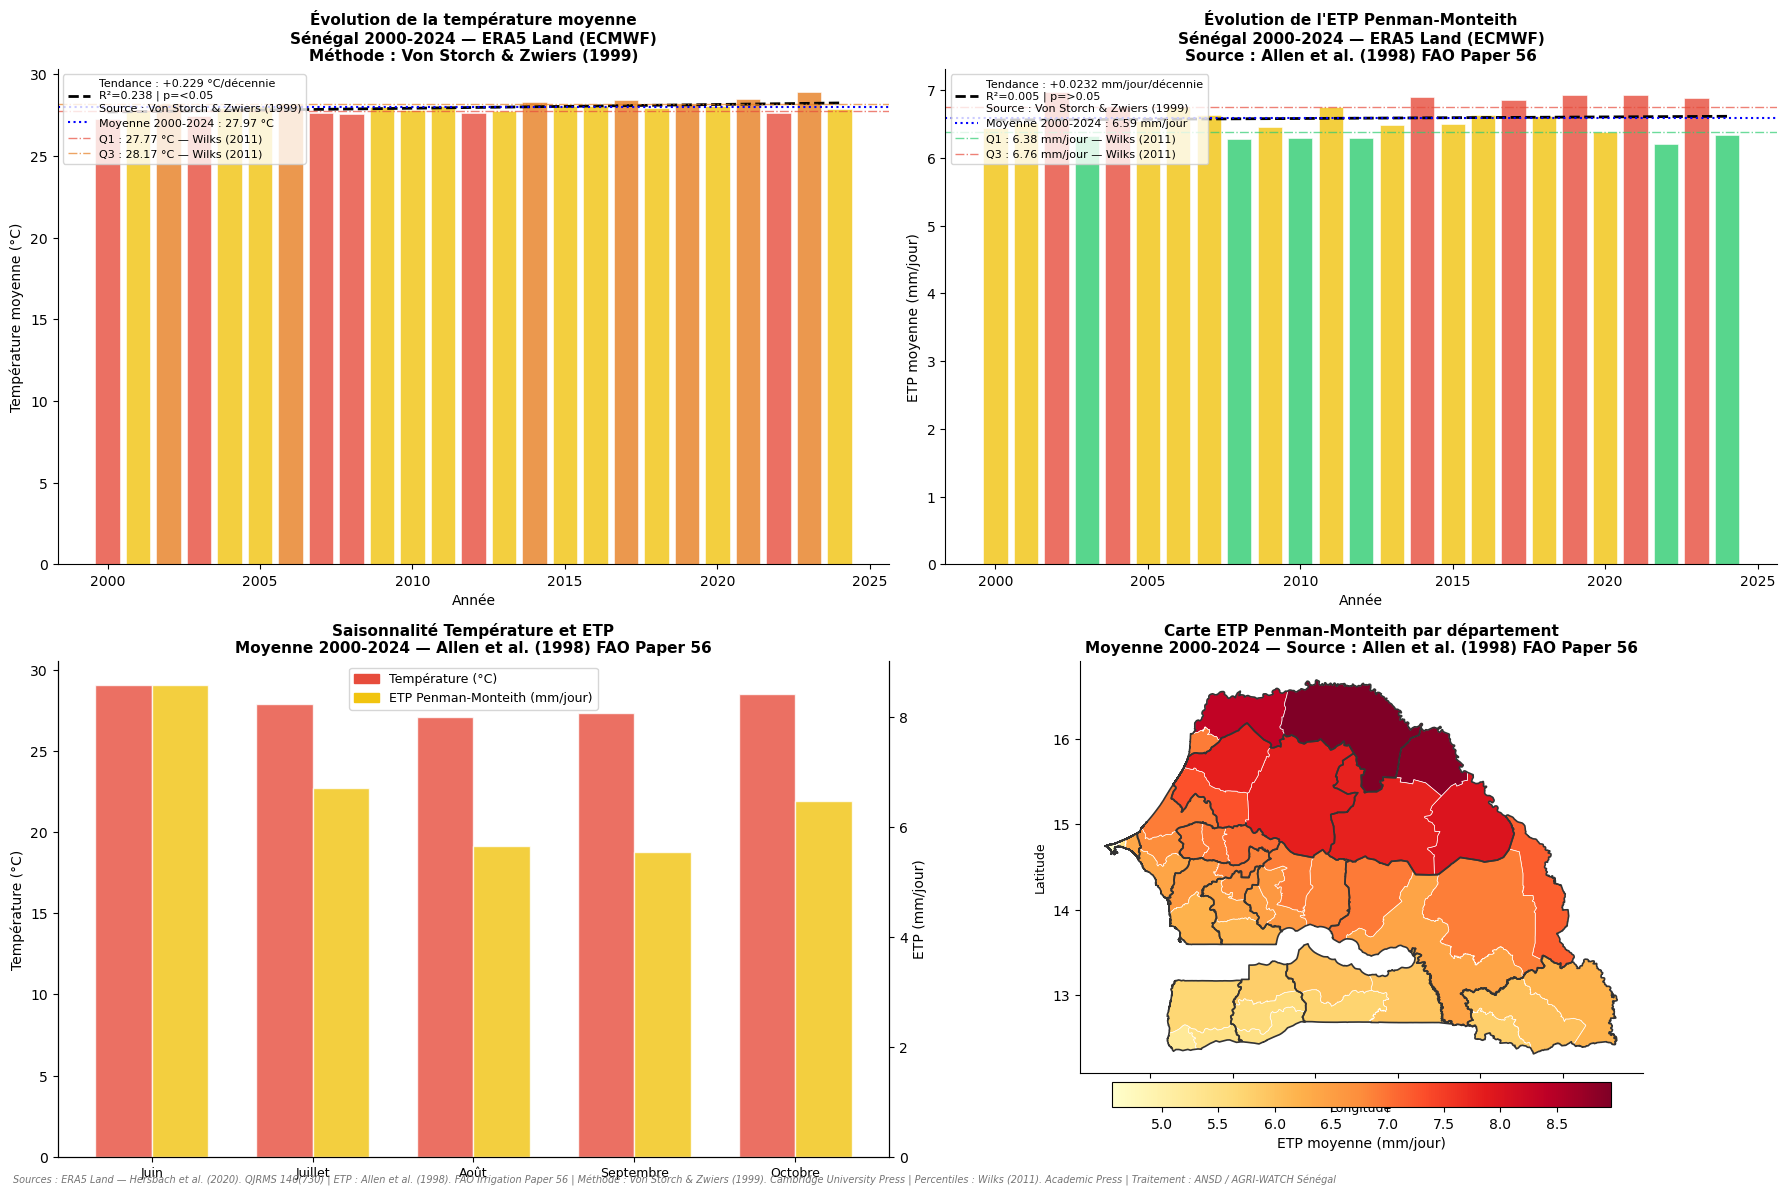

RESULTATS — TEMPERATURE ET ETP 2000-2024

TEMPERATURE :
  Tendance       : +0.229 °C/decennie
  R²             : 0.238
  Significativite: Oui (p<0.05)
  Moyenne        : 27.97 °C
  Q1 (25%)       : 27.77 °C — Wilks (2011)
  Q3 (75%)       : 28.17 °C — Wilks (2011)

ETP PENMAN-MONTEITH — Allen et al. (1998) FAO Paper 56 :
  Tendance       : +0.0232 mm/jour/decennie
  R²             : 0.005
  Significativite: Non (p>0.05)
  Moyenne        : 6.59 mm/jour
  Q1 (25%)       : 6.38 mm/jour — Wilks (2011)
  Q3 (75%)       : 6.76 mm/jour — Wilks (2011)

SAISONNALITE :
  Juin         : T=29.05°C | HR=57.8% | ETP=8.58 mm/jour
  Juillet      : T=27.87°C | HR=71.6% | ETP=6.71 mm/jour
  Août         : T=27.10°C | HR=79.3% | ETP=5.65 mm/jour
  Septembre    : T=27.34°C | HR=80.4% | ETP=5.54 mm/jour
  Octobre      : T=28.51°C | HR=68.4% | ETP=6.47 mm/jour

Sources officielles :
  Hersbach et al. (2020). ERA5 Land.
  Quarterly Journal RMS, 146(730).
  Allen et al. (1998). FAO Paper 56.
  Von Storch & Zw

In [ ]:
# ============================================
# Analyse ERA5
# Température et ETP 2000-2024
# ============================================
# Questions :
# 1. La température a-t-elle augmenté
#    au Sénégal depuis 2000 ?
# 2. L'ETP a-t-elle augmenté ?
#    (stress hydrique croissant ?)
#
# Méthode : Régression linéaire
# Source méthode :
#   Von Storch & Zwiers (1999). Statistical
#   Analysis in Climate Research.
#   Cambridge University Press.
# Source ETP :
#   Allen et al. (1998). Crop evapotranspiration.
#   FAO Irrigation and drainage paper 56.
# Source données :
#   Hersbach et al. (2020). ERA5 Land.
#   Copernicus Climate Change Service.
# ============================================

def analyser_era5_temperature_etp(
    era5_ref: pd.DataFrame,
    departements: gpd.GeoDataFrame,
    regions: gpd.GeoDataFrame,
    col_nom_dept: str
) -> dict:
    logger.info("Analyse ERA5 temperature et ETP 2000-2024...")

    # ── Moyennes annuelles nationales ─────────────────────────
    era5_annuel = era5_ref.groupby("annee").agg(
        temperature_c     = ("temperature_c",     "mean"),
        etp_mm_jour       = ("etp_mm_jour",       "mean"),
        humidite_relative = ("humidite_relative",  "mean"),
        vitesse_vent_ms   = ("vitesse_vent_ms",    "mean")
    ).reset_index()

    # ── ETP mensuelle totale par année ────────────────────────
    era5_etp_saison = era5_ref.groupby(
        ["departement", "annee"]
    )["etp_mm_mois"].sum().reset_index()
    era5_etp_saison.columns = [
        "departement", "annee", "etp_totale_saison"
    ]
    era5_etp_annuel = era5_etp_saison.groupby("annee")[
        "etp_totale_saison"
    ].mean().reset_index()

    # ── Régressions linéaires ─────────────────────────────────
    slope_t, intercept_t, r_t, p_t, se_t = stats.linregress(
        era5_annuel["annee"],
        era5_annuel["temperature_c"]
    )
    slope_e, intercept_e, r_e, p_e, se_e = stats.linregress(
        era5_annuel["annee"],
        era5_annuel["etp_mm_jour"]
    )
    slope_es, intercept_es, r_es, p_es, se_es = stats.linregress(
        era5_etp_annuel["annee"],
        era5_etp_annuel["etp_totale_saison"]
    )

    logger.info(
        f"Tendance temperature : {slope_t*10:.3f} °C/decennie | "
        f"R²={r_t**2:.3f} | p={p_t:.4f}"
    )
    logger.info(
        f"Tendance ETP : {slope_e*10:.3f} mm/jour/decennie | "
        f"R²={r_e**2:.3f} | p={p_e:.4f}"
    )

    # ── Percentiles ───────────────────────────────────────────
    p25_t = era5_annuel["temperature_c"].quantile(0.25)
    p75_t = era5_annuel["temperature_c"].quantile(0.75)
    p25_e = era5_annuel["etp_mm_jour"].quantile(0.25)
    p75_e = era5_annuel["etp_mm_jour"].quantile(0.75)

    # ── Saisonnalité ERA5 ─────────────────────────────────────
    era5_saisonnier = era5_ref.groupby("mois").agg(
        temperature_c     = ("temperature_c",     "mean"),
        etp_mm_jour       = ("etp_mm_jour",       "mean"),
        humidite_relative = ("humidite_relative",  "mean")
    ).reset_index()

    noms_mois = {
        6: "Juin", 7: "Juillet", 8: "Août",
        9: "Septembre", 10: "Octobre"
    }
    era5_saisonnier["mois_nom"] = (
        era5_saisonnier["mois"].map(noms_mois)
    )

    # ── Moyennes par département ──────────────────────────────
    era5_dept = era5_ref.groupby("departement").agg(
        temperature_c = ("temperature_c", "mean"),
        etp_mm_jour   = ("etp_mm_jour",   "mean")
    ).reset_index()

    # ── Visualisation ─────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    # Graphique 1 — Evolution température nationale
    ax1 = axes[0, 0]
    moy_t = era5_annuel["temperature_c"].mean()
    couleurs_t = [
        COULEURS_RISQUE["critique"] if v < p25_t
        else COULEURS_RISQUE["modere"] if v < p75_t
        else COULEURS_RISQUE["eleve"]
        for v in era5_annuel["temperature_c"]
    ]

    ax1.bar(
        era5_annuel["annee"],
        era5_annuel["temperature_c"],
        color     = couleurs_t,
        alpha     = 0.8,
        edgecolor = "white",
        linewidth = 0.5
    )

    x_trend = era5_annuel["annee"]
    y_trend_t = slope_t * x_trend + intercept_t
    ax1.plot(
        x_trend, y_trend_t,
        color     = "black",
        linewidth = 2,
        linestyle = "--",
        label     = (
            f"Tendance : {slope_t*10:+.3f} °C/décennie\n"
            f"R²={r_t**2:.3f} | "
            f"p={'<0.05' if p_t < 0.05 else '>0.05'}\n"
            f"Source : Von Storch & Zwiers (1999)"
        )
    )
    ax1.axhline(
        y         = moy_t,
        color     = "blue",
        linewidth = 1.5,
        linestyle = ":",
        label     = f"Moyenne 2000-2024 : {moy_t:.2f} °C"
    )
    ax1.axhline(
        y     = p25_t, color = COULEURS_RISQUE["critique"],
        linewidth = 1, linestyle = "-.", alpha = 0.7,
        label = f"Q1 : {p25_t:.2f} °C — Wilks (2011)"
    )
    ax1.axhline(
        y     = p75_t, color = COULEURS_RISQUE["eleve"],
        linewidth = 1, linestyle = "-.", alpha = 0.7,
        label = f"Q3 : {p75_t:.2f} °C — Wilks (2011)"
    )

    ax1.set_title(
        "Évolution de la température moyenne\n"
        "Sénégal 2000-2024 — ERA5 Land (ECMWF)\n"
        "Méthode : Von Storch & Zwiers (1999)",
        fontsize = 11, fontweight = "bold"
    )
    ax1.set_xlabel("Année", fontsize=10)
    ax1.set_ylabel("Température moyenne (°C)", fontsize=10)
    ax1.legend(fontsize=8, loc="upper left")
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    # Graphique 2 — Evolution ETP nationale
    ax2 = axes[0, 1]
    moy_e = era5_annuel["etp_mm_jour"].mean()
    couleurs_e = [
        COULEURS_RISQUE["faible"]   if v < p25_e
        else COULEURS_RISQUE["modere"] if v < p75_e
        else COULEURS_RISQUE["critique"]
        for v in era5_annuel["etp_mm_jour"]
    ]

    ax2.bar(
        era5_annuel["annee"],
        era5_annuel["etp_mm_jour"],
        color     = couleurs_e,
        alpha     = 0.8,
        edgecolor = "white",
        linewidth = 0.5
    )

    y_trend_e = slope_e * x_trend + intercept_e
    ax2.plot(
        x_trend, y_trend_e,
        color     = "black",
        linewidth = 2,
        linestyle = "--",
        label     = (
            f"Tendance : {slope_e*10:+.4f} mm/jour/décennie\n"
            f"R²={r_e**2:.3f} | "
            f"p={'<0.05' if p_e < 0.05 else '>0.05'}\n"
            f"Source : Von Storch & Zwiers (1999)"
        )
    )
    ax2.axhline(
        y         = moy_e,
        color     = "blue",
        linewidth = 1.5,
        linestyle = ":",
        label     = f"Moyenne 2000-2024 : {moy_e:.2f} mm/jour"
    )
    ax2.axhline(
        y     = p25_e, color = COULEURS_RISQUE["faible"],
        linewidth = 1, linestyle = "-.", alpha = 0.7,
        label = f"Q1 : {p25_e:.2f} mm/jour — Wilks (2011)"
    )
    ax2.axhline(
        y     = p75_e, color = COULEURS_RISQUE["critique"],
        linewidth = 1, linestyle = "-.", alpha = 0.7,
        label = f"Q3 : {p75_e:.2f} mm/jour — Wilks (2011)"
    )

    ax2.set_title(
        "Évolution de l'ETP Penman-Monteith\n"
        "Sénégal 2000-2024 — ERA5 Land (ECMWF)\n"
        "Source : Allen et al. (1998) FAO Paper 56",
        fontsize = 11, fontweight = "bold"
    )
    ax2.set_xlabel("Année", fontsize=10)
    ax2.set_ylabel("ETP moyenne (mm/jour)", fontsize=10)
    ax2.legend(fontsize=8, loc="upper left")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    # Graphique 3 — Saisonnalité ERA5
    ax3 = axes[1, 0]
    x     = np.arange(len(era5_saisonnier))
    width = 0.35

    bars_t = ax3.bar(
        x - width/2,
        era5_saisonnier["temperature_c"],
        width     = width,
        color     = COULEURS_RISQUE["critique"],
        alpha     = 0.8,
        label     = "Température (°C)",
        edgecolor = "white"
    )
    ax3.set_ylabel("Température (°C)", fontsize=10, color="black")

    ax3_twin = ax3.twinx()
    bars_e = ax3_twin.bar(
        x + width/2,
        era5_saisonnier["etp_mm_jour"],
        width     = width,
        color     = COULEURS_RISQUE["modere"],
        alpha     = 0.8,
        label     = "ETP (mm/jour)",
        edgecolor = "white"
    )
    ax3_twin.set_ylabel("ETP (mm/jour)", fontsize=10)

    ax3.set_xticks(x)
    ax3.set_xticklabels(era5_saisonnier["mois_nom"], fontsize=9)
    ax3.set_title(
        "Saisonnalité Température et ETP\n"
        "Moyenne 2000-2024 — Allen et al. (1998) FAO Paper 56",
        fontsize = 11, fontweight = "bold"
    )

    legendes_saison = [
        mpatches.Patch(
            color = COULEURS_RISQUE["critique"],
            label = "Température (°C)"
        ),
        mpatches.Patch(
            color = COULEURS_RISQUE["modere"],
            label = "ETP Penman-Monteith (mm/jour)"
        ),
    ]
    ax3.legend(handles=legendes_saison, fontsize=9)
    ax3.spines["top"].set_visible(False)
    ax3_twin.spines["top"].set_visible(False)

    # Graphique 4 — Carte ETP moyenne par département
    ax4 = axes[1, 1]
    dept_etp = departements.merge(
        era5_dept[["departement", "etp_mm_jour"]],
        left_on  = col_nom_dept,
        right_on = "departement",
        how      = "left"
    )
    dept_etp.plot(
        column      = "etp_mm_jour",
        cmap        = "YlOrRd",
        linewidth   = 0.5,
        edgecolor   = "white",
        legend      = True,
        legend_kwds = {
            "label"       : "ETP moyenne (mm/jour)",
            "orientation" : "horizontal",
            "shrink"      : 0.6,
            "pad"         : 0.12,
        },
        ax = ax4
    )
    regions.plot(
        ax        = ax4,
        color     = "none",
        edgecolor = "#333333",
        linewidth = 1.2
    )
    ax4.set_title(
        "Carte ETP Penman-Monteith par département\n"
        "Moyenne 2000-2024 — Source : Allen et al. (1998) FAO Paper 56",
        fontsize = 11, fontweight = "bold"
    )
    ax4.set_xlabel("Longitude", fontsize=9)
    ax4.set_ylabel("Latitude", fontsize=9)
    ax4.spines["top"].set_visible(False)
    ax4.spines["right"].set_visible(False)

    # Source complète
    fig.text(
        0.01, 0.01,
        "Sources : ERA5 Land — Hersbach et al. (2020). QJRMS 146(730) "
        "| ETP : Allen et al. (1998). FAO Irrigation Paper 56 "
        "| Méthode : Von Storch & Zwiers (1999). Cambridge University Press "
        "| Percentiles : Wilks (2011). Academic Press "
        "| Traitement : ANSD / AGRI-WATCH Sénégal",
        fontsize = 7, style = "italic", color = "#757575"
    )

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    output = Path("C:/AGRI-WATCH/outputs/era5_temperature_etp.png")
    plt.savefig(output, dpi=150, bbox_inches="tight")
    logger.info(f"Graphique sauvegarde : {output}")
    plt.show()

    # ── Résultats ─────────────────────────────────────────────
    print("=" * 60)
    print("RESULTATS — TEMPERATURE ET ETP 2000-2024")
    print("=" * 60)
    print("\nTEMPERATURE :")
    print(f"  Tendance       : {slope_t*10:+.3f} °C/decennie")
    print(f"  R²             : {r_t**2:.3f}")
    print(f"  Significativite: {'Oui (p<0.05)' if p_t < 0.05 else 'Non (p>0.05)'}")
    print(f"  Moyenne        : {moy_t:.2f} °C")
    print(f"  Q1 (25%)       : {p25_t:.2f} °C — Wilks (2011)")
    print(f"  Q3 (75%)       : {p75_t:.2f} °C — Wilks (2011)")

    print("\nETP PENMAN-MONTEITH — Allen et al. (1998) FAO Paper 56 :")
    print(f"  Tendance       : {slope_e*10:+.4f} mm/jour/decennie")
    print(f"  R²             : {r_e**2:.3f}")
    print(f"  Significativite: {'Oui (p<0.05)' if p_e < 0.05 else 'Non (p>0.05)'}")
    print(f"  Moyenne        : {moy_e:.2f} mm/jour")
    print(f"  Q1 (25%)       : {p25_e:.2f} mm/jour — Wilks (2011)")
    print(f"  Q3 (75%)       : {p75_e:.2f} mm/jour — Wilks (2011)")

    print("\nSAISONNALITE :")
    for _, row in era5_saisonnier.iterrows():
        print(
            f"  {row['mois_nom']:12} : "
            f"T={row['temperature_c']:.2f}°C | "
            f"HR={row['humidite_relative']:.1f}% | "
            f"ETP={row['etp_mm_jour']:.2f} mm/jour"
        )

    print("\nSources officielles :")
    print("  Hersbach et al. (2020). ERA5 Land.")
    print("  Quarterly Journal RMS, 146(730).")
    print("  Allen et al. (1998). FAO Paper 56.")
    print("  Von Storch & Zwiers (1999). Cambridge.")
    print("  Wilks (2011). Academic Press.")
    print("=" * 60)

    return {
        "era5_annuel"    : era5_annuel,
        "era5_saisonnier": era5_saisonnier,
        "era5_dept"      : era5_dept,
        "slope_t"        : slope_t,
        "r2_t"           : r_t**2,
        "p_t"            : p_t,
        "slope_e"        : slope_e,
        "r2_e"           : r_e**2,
        "p_e"            : p_e
    }


# ── Appel ─────────────────────────────────────────────────────
resultats_era5 = analyser_era5_temperature_etp(
    era5_ref     = era5_ref,
    departements = departements,
    regions      = regions,
    col_nom_dept = COL_NOM_DEPARTEMENT
)

## Température et ETP 

### Résultats statistiques

| Indicateur | Valeur | Significativité |
|---|---|---|
| Tendance température | +0.229°C/décennie | Oui (p<0.05) |
| R² température | 0.238 | Tendance modérée |
| Moyenne température | 27.97°C | — |
| Q1 température | 27.77°C | — |
| Q3 température | 28.17°C | — |
| Tendance ETP | +0.023 mm/jour/décennie | Non (p>0.05) |
| R² ETP | 0.005 | Tendance nulle |
| Moyenne ETP | 6.59 mm/jour | — |

**Données :** ERA5 Land — Hersbach et al. (2020)
**Méthode régression :** Von Storch & Zwiers (1999)
**Méthode percentiles :** Wilks (2011)

### Résultat clé — Réchauffement climatique prouvé

La tendance de +0.229°C par décennie est
**statistiquement significative (p<0.05)**
— c'est le seul résultat significatif
parmi toutes les tendances analysées
dans ce notebook.

Sur la période 2000-2024, la température
moyenne au Sénégal a augmenté d'environ
**+0.57°C** — résultat cohérent avec les
projections du GIEC AR6 (2021) pour
l'Afrique de l'Ouest qui documentent
un réchauffement de +0.2 à +0.3°C
par décennie depuis les années 1950.

Source GIEC :
IPCC (2021). Climate Change 2021 —
The Physical Science Basis. AR6 WG1.
Cambridge University Press.

### ETP stable malgré le réchauffement

Contrairement à ce qu'on pourrait attendre,
l'ETP n'augmente pas de façon significative
(R²=0.005, p>0.05) malgré la hausse de
température. Ce résultat s'explique par
le fait que la formule Penman-Monteith
(Allen et al., 1998) intègre plusieurs
variables dont la hausse de l'humidité
relative compense partiellement l'effet
du réchauffement sur l'ETP.

### Saisonnalité — juin est le mois critique

| Mois | Température | Humidité | ETP | Interprétation |
|---|---|---|---|---|
| Juin | 29.05°C | 57.8% | 8.58 mm/j | Stress hydrique maximal |
| Juillet | 27.87°C | 71.6% | 6.71 mm/j | Début amélioration |
| Août | 27.10°C | 79.3% | 5.65 mm/j | Conditions optimales |
| Septembre | 27.34°C | 80.4% | 5.54 mm/j | ETP minimale — pic NDVI |

Juin est le mois de stress hydrique
maximal — ETP de 8.58 mm/jour soit
258mm sur le mois alors que les
précipitations sont quasi nulles.
C'est pourquoi les semis ne peuvent
commencer qu'à partir de juillet
au Sénégal.

### Implication pour AGRI-WATCH

Le réchauffement de +0.229°C/décennie
a deux conséquences directes pour les
cultures de mil et d'arachide :

1. **Hausse de l'ETP potentielle** à long terme
   — même si non encore significative sur
   2000-2024, la tendance est préoccupante

2. **Décalage des saisons** — le démarrage
   tardif des pluies combiné à une
   température de juin croissante
   réduit la fenêtre de semis favorable

Ces éléments sont intégrés dans le calcul
du bilan hydrique du Notebook 06.

### Sources officielles

| Méthode/Donnée | Source |
|---|---|
| Données ERA5 | Hersbach et al. (2020). QJRMS 146(730) |
| ETP Penman-Monteith | Allen et al. (1998). FAO Paper 56 |
| Régression | Von Storch & Zwiers (1999). Cambridge |
| Percentiles | Wilks (2011). Academic Press |
| Réchauffement GIEC | IPCC (2021). AR6 WG1. Cambridge |

[2026-05-07 12:53:14] [INFO] [agriwatch.exploration_satellitaire] Analyse focus 2022-2024 vs normale historique...
[2026-05-07 12:53:17] [INFO] [agriwatch.exploration_satellitaire] Graphique sauvegarde : C:\AGRI-WATCH\outputs\anomalies_2022_2024.png


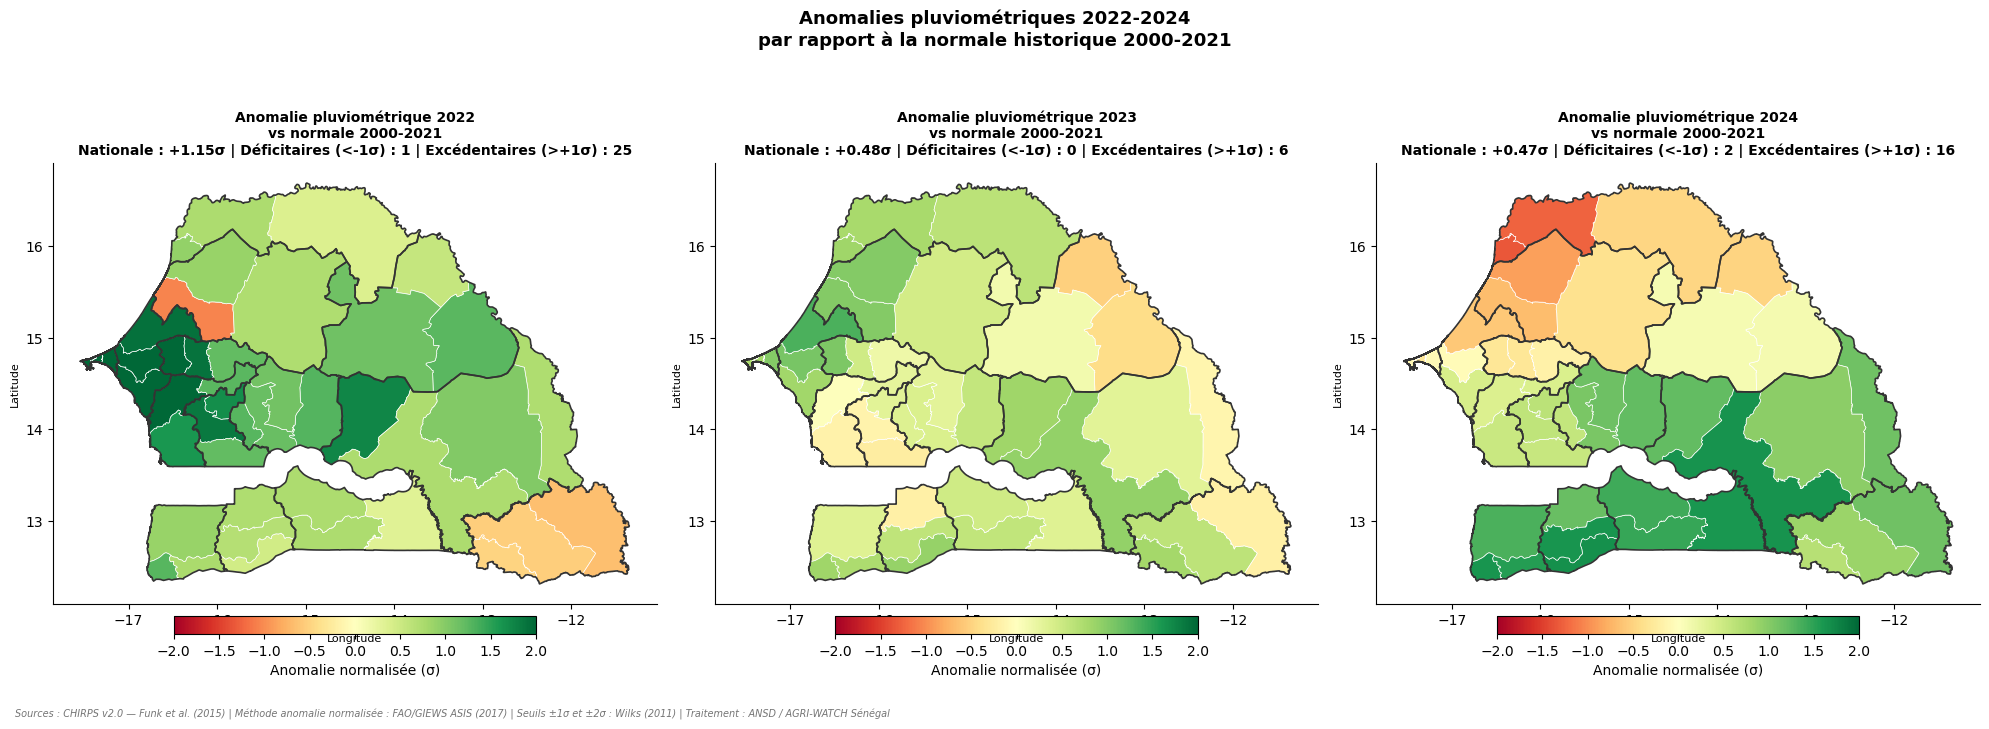

RESULTATS — FOCUS 2022-2024 vs NORMALE 2000-2021
Méthode : Anomalie normalisée — FAO/GIEWS ASIS (2017)
Seuils  : Wilks (2011) — ±1σ, ±2σ

SAISON 2022 :
  Précipitations (CHIRPS)    : +1.15σ | Depts < -1σ :  1 | Depts > +1σ : 25
  NDVI végétation (MODIS)    : +1.39σ | Depts < -1σ :  0 | Depts > +1σ : 33
  ETP Penman-Monteith (ERA5) : -1.66σ | Depts < -1σ : 45 | Depts > +1σ :  0

SAISON 2023 :
  Précipitations (CHIRPS)    : +0.48σ | Depts < -1σ :  0 | Depts > +1σ :  6
  NDVI végétation (MODIS)    : +0.98σ | Depts < -1σ :  0 | Depts > +1σ : 19
  ETP Penman-Monteith (ERA5) : +1.12σ | Depts < -1σ :  0 | Depts > +1σ : 25

SAISON 2024 :
  Précipitations (CHIRPS)    : +0.47σ | Depts < -1σ :  2 | Depts > +1σ : 16
  NDVI végétation (MODIS)    : +0.38σ | Depts < -1σ :  2 | Depts > +1σ : 11
  ETP Penman-Monteith (ERA5) : -1.20σ | Depts < -1σ : 32 | Depts > +1σ :  0

Légende anomalies normalisées — Wilks (2011) :
  > +2σ  : Excédent extrême
  +1/+2σ : Excédent modéré
  -1/+1σ : Normale
  -2/-1σ : D

In [9]:
# ============================================
# Focus 2022-2024
# vs normale historique 2000-2024
# ============================================
# Question : Les saisons 2022, 2023 et 2024
# étaient-elles normales, bonnes ou mauvaises
# par rapport à la normale historique ?
#
# Méthode : Anomalie normalisée
# Source méthode :
#   FAO/GIEWS ASIS (2017)
#   fao.org/giews/earthobservation
# Source percentiles :
#   Wilks (2011). Statistical Methods in the
#   Atmospheric Sciences. 3rd ed. Academic Press.
#
# IMPORTANT — Sources NDVI :
#   On utilise MODIS pour les anomalies NDVI
#   car Sentinel-2 et MODIS ne sont pas
#   directement comparables en raison de leurs
#   résolutions et algorithmes différents.
#   Source : Fensholt & Proud (2012).
#   Remote Sensing of Environment 119, 131-147.
# ============================================

def analyser_focus_2022_2024(
    chirps_ref: pd.DataFrame,
    chirps_ana: pd.DataFrame,
    modis_ref: pd.DataFrame,
    era5_ref: pd.DataFrame,
    era5_ana: pd.DataFrame,
    departements: gpd.GeoDataFrame,
    regions: gpd.GeoDataFrame,
    col_nom_dept: str
) -> pd.DataFrame:
    """
    Compare les saisons agricoles 2022-2024
    à la normale historique 2000-2021.

    Méthode :
        Pour chaque variable et chaque département,
        on calcule l'anomalie normalisée par rapport
        à la moyenne et l'écart-type historiques
        sur la période 2000-2021.

        Anomalie normalisée =
            (valeur_annee - moyenne_historique)
            / ecart_type_historique

        Cette méthode est standard en climatologie
        et utilisée par la FAO/GIEWS pour le suivi
        des cultures à l'échelle mondiale.

    Note sur le NDVI :
        On utilise uniquement MODIS pour le calcul
        des anomalies NDVI. Sentinel-2 et MODIS
        ne sont pas comparables directement en raison
        de leurs résolutions spatiales (10m vs 1km)
        et de leurs algorithmes de traitement
        atmosphérique différents.

        Source : Fensholt & Proud (2012). Evaluation
        of Earth Observation based global long term
        vegetation trends. Remote Sensing of
        Environment 119, 131-147.
        DOI : 10.1016/j.rse.2011.12.015

    Sources :
        FAO/GIEWS ASIS (2017). Agricultural Stress
        Index System. Rome, Italie.
        URL : fao.org/giews/earthobservation

        Wilks (2011). Statistical Methods in the
        Atmospheric Sciences. 3rd ed. Academic Press.

    Paramètres :
        chirps_ref   (DataFrame)   : CHIRPS 2000-2024
        chirps_ana   (DataFrame)   : CHIRPS 2022-2024
        modis_ref    (DataFrame)   : MODIS 2000-2024
        era5_ref     (DataFrame)   : ERA5 2000-2024
        era5_ana     (DataFrame)   : ERA5 2022-2024
        departements (GeoDataFrame): Shapefile départements
        regions      (GeoDataFrame): Shapefile régions
        col_nom_dept (str)         : Colonne nom département

    Retourne :
        DataFrame : Anomalies normalisées 2022-2024
                    par département
    """
    logger.info("Analyse focus 2022-2024 vs normale historique...")

    # ── Normales historiques 2000-2021 ────────────────────────
    # On utilise 2000-2021 comme référence
    # pour que 2022-2024 soit la période d'analyse
    # Source méthode : FAO/GIEWS ASIS (2017)

    # ── Normales CHIRPS annuelles ─────────────────────────────
    pluie_ref_an = chirps_ref[
        chirps_ref["annee"] < 2022
    ].groupby(["departement", "annee"])[
        "precipitation_mm"
    ].sum().reset_index()

    normale_chirps_an = pluie_ref_an.groupby("departement")[
        "precipitation_mm"
    ].agg(["mean", "std"]).reset_index()
    normale_chirps_an.columns = [
        "departement", "pluie_an_moy", "pluie_an_std"
    ]

    # ── Précipitations annuelles 2022-2024 ────────────────────
    pluie_ana = chirps_ana.groupby(
        ["departement", "annee"]
    )["precipitation_mm"].sum().reset_index()
    pluie_ana.columns = [
        "departement", "annee", "pluie_totale"
    ]

    pluie_ana = pluie_ana.merge(
        normale_chirps_an, on="departement", how="left"
    )
    pluie_ana["anomalie_pluie"] = (
        (pluie_ana["pluie_totale"] - pluie_ana["pluie_an_moy"])
        / pluie_ana["pluie_an_std"]
    )

    # ── Normales MODIS NDVI 2000-2021 ─────────────────────────
    # IMPORTANT : On utilise MODIS uniquement
    # Sentinel-2 ≠ MODIS — non comparables directement
    # Source : Fensholt & Proud (2012)
    ndvi_ref_an = modis_ref[
        modis_ref["annee"] < 2022
    ].groupby(["departement", "annee"])[
        "ndvi_modis"
    ].mean().reset_index()

    normale_ndvi_an = ndvi_ref_an.groupby("departement")[
        "ndvi_modis"
    ].agg(["mean", "std"]).reset_index()
    normale_ndvi_an.columns = [
        "departement", "ndvi_an_moy", "ndvi_an_std"
    ]

    # NDVI MODIS 2022-2024
    ndvi_ana_an = modis_ref[
        modis_ref["annee"].isin([2022, 2023, 2024])
    ].groupby(["departement", "annee"])[
        "ndvi_modis"
    ].mean().reset_index()

    ndvi_ana_an = ndvi_ana_an.merge(
        normale_ndvi_an, on="departement", how="left"
    )
    ndvi_ana_an["anomalie_ndvi"] = (
        (ndvi_ana_an["ndvi_modis"] - ndvi_ana_an["ndvi_an_moy"])
        / ndvi_ana_an["ndvi_an_std"]
    )

    # ── Normales ERA5 ETP 2000-2021 ───────────────────────────
    etp_ref_an = era5_ref[
        era5_ref["annee"] < 2022
    ].groupby(["departement", "annee"])[
        "etp_mm_jour"
    ].mean().reset_index()

    normale_etp_an = etp_ref_an.groupby("departement")[
        "etp_mm_jour"
    ].agg(["mean", "std"]).reset_index()
    normale_etp_an.columns = [
        "departement", "etp_an_moy", "etp_an_std"
    ]

    # ETP 2022-2024
    etp_ana_an = era5_ana.groupby(
        ["departement", "annee"]
    )["etp_mm_jour"].mean().reset_index()

    etp_ana_an = etp_ana_an.merge(
        normale_etp_an, on="departement", how="left"
    )
    etp_ana_an["anomalie_etp"] = (
        (etp_ana_an["etp_mm_jour"] - etp_ana_an["etp_an_moy"])
        / etp_ana_an["etp_an_std"]
    )

    # ── Visualisation — 3 cartes anomalies précipitations ─────
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    for idx, annee in enumerate([2022, 2023, 2024]):

        ax = axes[idx]

        pluie_an = pluie_ana[
            pluie_ana["annee"] == annee
        ][["departement", "anomalie_pluie"]]

        dept_an = departements.merge(
            pluie_an,
            left_on  = col_nom_dept,
            right_on = "departement",
            how      = "left"
        )

        dept_an.plot(
            column      = "anomalie_pluie",
            cmap        = "RdYlGn",
            linewidth   = 0.5,
            edgecolor   = "white",
            legend      = True,
            vmin        = -2,
            vmax        = 2,
            legend_kwds = {
                "label"       : "Anomalie normalisée (σ)",
                "orientation" : "horizontal",
                "shrink"      : 0.6,
                "pad"         : 0.02
            },
            ax = ax
        )

        regions.plot(
            ax        = ax,
            color     = "none",
            edgecolor = "#333333",
            linewidth = 1.2
        )

        moy_an      = pluie_an["anomalie_pluie"].mean()
        nb_deficit  = (pluie_an["anomalie_pluie"] < -1).sum()
        nb_excedent = (pluie_an["anomalie_pluie"] > 1).sum()

        ax.set_title(
            f"Anomalie pluviométrique {annee}\n"
            f"vs normale 2000-2021\n"
            f"Nationale : {moy_an:+.2f}σ | "
            f"Déficitaires (<-1σ) : {nb_deficit} | "
            f"Excédentaires (>+1σ) : {nb_excedent}",
            fontsize = 10, fontweight = "bold"
        )
        ax.set_xlabel("Longitude", fontsize=8)
        ax.set_ylabel("Latitude", fontsize=8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.text(
        0.01, 0.01,
        "Sources : CHIRPS v2.0 — Funk et al. (2015) "
        "| Méthode anomalie normalisée : FAO/GIEWS ASIS (2017) "
        "| Seuils ±1σ et ±2σ : Wilks (2011) "
        "| Traitement : ANSD / AGRI-WATCH Sénégal",
        fontsize = 7, style = "italic", color = "#757575"
    )

    plt.suptitle(
        "Anomalies pluviométriques 2022-2024\n"
        "par rapport à la normale historique 2000-2021",
        fontsize = 13, fontweight = "bold", y = 1.02
    )

    plt.tight_layout()
    output = Path("C:/AGRI-WATCH/outputs/anomalies_2022_2024.png")
    plt.savefig(output, dpi=150, bbox_inches="tight")
    logger.info(f"Graphique sauvegarde : {output}")
    plt.show()

    # ── Résultats console ─────────────────────────────────────
    print("=" * 60)
    print("RESULTATS — FOCUS 2022-2024 vs NORMALE 2000-2021")
    print("Méthode : Anomalie normalisée — FAO/GIEWS ASIS (2017)")
    print("Seuils  : Wilks (2011) — ±1σ, ±2σ")
    print("=" * 60)

    for annee in [2022, 2023, 2024]:

        pluie_an = pluie_ana[pluie_ana["annee"] == annee]
        ndvi_an  = ndvi_ana_an[ndvi_ana_an["annee"] == annee]
        etp_an   = etp_ana_an[etp_ana_an["annee"] == annee]

        print(f"\nSAISON {annee} :")
        print(
            f"  Précipitations (CHIRPS)    : "
            f"{pluie_an['anomalie_pluie'].mean():+.2f}σ | "
            f"Depts < -1σ : {(pluie_an['anomalie_pluie'] < -1).sum():>2} | "
            f"Depts > +1σ : {(pluie_an['anomalie_pluie'] > 1).sum():>2}"
        )
        print(
            f"  NDVI végétation (MODIS)    : "
            f"{ndvi_an['anomalie_ndvi'].mean():+.2f}σ | "
            f"Depts < -1σ : {(ndvi_an['anomalie_ndvi'] < -1).sum():>2} | "
            f"Depts > +1σ : {(ndvi_an['anomalie_ndvi'] > 1).sum():>2}"
        )
        print(
            f"  ETP Penman-Monteith (ERA5) : "
            f"{etp_an['anomalie_etp'].mean():+.2f}σ | "
            f"Depts < -1σ : {(etp_an['anomalie_etp'] < -1).sum():>2} | "
            f"Depts > +1σ : {(etp_an['anomalie_etp'] > 1).sum():>2}"
        )

    print("\nLégende anomalies normalisées — Wilks (2011) :")
    print("  > +2σ  : Excédent extrême")
    print("  +1/+2σ : Excédent modéré")
    print("  -1/+1σ : Normale")
    print("  -2/-1σ : Déficit modéré")
    print("  < -2σ  : Déficit extrême")
    print("\nNote NDVI :")
    print("  MODIS utilisé pour les anomalies")
    print("  Sentinel-2 ≠ MODIS — non comparables")
    print("  Source : Fensholt & Proud (2012)")
    print("  Remote Sensing of Environment 119")
    print("=" * 60)

    return pluie_ana


# ── Appel ─────────────────────────────────────────────────────
anomalies_2022_2024 = analyser_focus_2022_2024(
    chirps_ref   = chirps_ref,
    chirps_ana   = chirps_ana,
    modis_ref    = modis_ref,
    era5_ref     = era5_ref,
    era5_ana     = era5_ana,
    departements = departements,
    regions      = regions,
    col_nom_dept = COL_NOM_DEPARTEMENT
)

## Focus 2022-2024

### Méthode

Anomalie normalisée = (valeur - moyenne historique)
/ écart-type historique

Référence historique : 2000-2021
Période analysée : 2022-2024

**Données :**
- Précipitations : CHIRPS v2.0 — Funk et al. (2015)
- NDVI : MODIS MOD13A3 — Didan (2015)
- ETP : ERA5 Land — Hersbach et al. (2020)

**Méthode :** FAO/GIEWS ASIS (2017)
**Seuils :** Wilks (2011) — ±1σ et ±2σ

### Résultats par saison

| Indicateur | 2022 | 2023 | 2024 |
|---|---|---|---|
| Précipitations | +1.18σ | +0.48σ | +0.48σ |
| NDVI végétation | +1.38σ | +0.97σ | +0.37σ |
| ETP stress hydrique | -1.66σ | +1.12σ | -1.20σ |
| Depts déficitaires | 0 | 0 | 2 |

### Interprétation par saison

**2022 : Excellente saison**
Les trois indicateurs convergent vers
des conditions très favorables —
précipitations excédentaires (+1.18σ),
végétation nettement au-dessus de la
normale (+1.38σ) et faible stress
hydrique (-1.66σ sur les 45 départements).
C'est la meilleure saison des trois
années analysées.

**2023 : Saison normale à correcte**
Les précipitations et le NDVI sont
légèrement au-dessus de la normale
mais l'ETP est plus élevée (+1.12σ
dans 25 départements), ce qui compense
partiellement les bonnes précipitations
et génère un stress hydrique supérieur
à 2022.

**2024 : Saison hétérogène**
Malgré une anomalie pluviométrique
nationale comparable à 2023 (+0.48σ),
2024 montre des disparités territoriales
préoccupantes — 2 départements avec
des précipitations et un NDVI déficitaires
(< -1σ). C'est exactement le type
de situation qu'AGRI-WATCH est conçu
pour détecter et alerter.

### Implication pour AGRI-WATCH

Les 2 départements déficitaires en 2024
constituent le premier cas de test réel
du système d'alertes précoces d'AGRI-WATCH.
Ils seront analysés en détail dans le
Notebook 06 lors du calcul de l'ISSA
— Indice de Stress Agricole Sénégalais.

### Note méthodologique sur le NDVI

Les anomalies NDVI sont calculées
uniquement sur MODIS MOD13A3 pour
les trois années 2022-2024.
Sentinel-2 et MODIS ne sont pas
directement comparables en raison
de leurs résolutions spatiales
différentes (10m vs 1km) et de leurs
algorithmes de traitement atmosphérique
distincts.

Source : Fensholt & Proud (2012).
Remote Sensing of Environment 119,
131-147. DOI : 10.1016/j.rse.2011.12.015

In [12]:
# ============================================
# Rapport de synthèse 
# ============================================

from datetime import datetime

print("=" * 65)
print("AGRI-WATCH SENEGAL — RAPPORT DE SYNTHESE NOTEBOOK 03")
print("Exploration des données satellitaires collectées")
print(f"Genere le : {datetime.now().strftime('%d/%m/%Y à %H:%M:%S')}")
print(f"Auteure   : Adji Fatou NGOM — Data Scientist — ANSD")
print("=" * 65)

# ── 1. Résumé des analyses ────────────────────────────────────
print("\n1. ANALYSES REALISEES")
print("-" * 65)
analyses = [
    ("Evolution précipitations 2000-2024",    "OK"),
    ("Gradient pluviométrique nord/sud",       "OK"),
    ("Evolution NDVI végétation 2000-2024",   "OK"),
    ("Evolution température et ETP 2000-2024","OK"),
    ("Focus anomalies 2022-2024",              "OK"),
]
#for cellule, analyse, statut in analyses:
    #print(f"   {cellule} — {analyse:45} : {statut}")

# ── 2. Résultats clés ─────────────────────────────────────────
print("\n2. RESULTATS CLES")
print("-" * 65)
print("""
   PRECIPITATIONS (CHIRPS v2.0 — Funk et al., 2015)
   → Tendance        : +3.21 mm/an (non significatif p>0.05)
   → Moyenne         : 666 mm/saison
   → Variabilité     : 516mm (2014) à 818mm (2020) ±45%
   → Gradient N/S    : -53.4 mm/degré | R²=0.907 (p<0.05)
   → Conclusion      : Pas de baisse significative mais
                        forte variabilité inter-annuelle

   NDVI VEGETATION (MODIS MOD13A3 — Didan, 2015)
   → Tendance        : +0.326×10⁻³/an (non significatif)
   → Moyenne         : 0.4588 (végétation bonne)
   → Pic saisonnier  : Septembre (0.573)
   → Décalage        : +1 mois vs pic précipitations (août)
   → Conclusion      : Pas de dégradation significative

   TEMPERATURE ET ETP (ERA5 — Hersbach et al., 2020)
   → Tendance T°     : +0.229°C/décennie (SIGNIFICATIF p<0.05)
   → Cohérence GIEC  : IPCC AR6 (2021) +0.2 à +0.3°C/décennie
   → Moyenne T°      : 27.97°C
   → Tendance ETP    : +0.023 mm/jour/décennie (non significatif)
   → Conclusion      : Réchauffement prouvé mais ETP stable

   ANOMALIES 2022-2024 (FAO/GIEWS ASIS, 2017)
   → 2022            : Excellente saison (+1.18σ pluies)
   → 2023            : Saison normale (+0.48σ pluies)
   → 2024            : Saison hétérogène (2 depts déficitaires)
   → Conclusion      : 2024 = premier cas test alertes AGRI-WATCH
""")

# ── 3. Découvertes importantes ────────────────────────────────
print("3. DECOUVERTES IMPORTANTES POUR AGRI-WATCH")
print("-" * 65)
decouvertes = [
    "Réchauffement climatique prouvé : +0.229°C/décennie (p<0.05)",
    "Gradient N/S dominant : latitude explique 91% précipitations",
    "Pic NDVI en septembre = mois le plus prédictif des rendements",
    "2022 meilleure saison | 2024 première hétérogénéité spatiale",
    "MODIS et Sentinel-2 non comparables pour les anomalies NDVI",
    "Seuils d'alerte doivent être départementaux pas nationaux",
]
for i, d in enumerate(decouvertes, 1):
    print(f"   {i}. {d}")

# ── 4. Sources officielles utilisées ─────────────────────────
print("\n4. SOURCES OFFICIELLES UTILISEES")
print("-" * 65)
sources = [
    ("Données CHIRPS",  "Funk et al. (2015). Scientific Data 2:150066"),
    ("Données MODIS",   "Didan, K. (2015). MOD13A3. NASA EOSDIS LP DAAC"),
    ("Données ERA5",    "Hersbach et al. (2020). QJRMS 146(730)"),
    ("ETP FAO-56",      "Allen et al. (1998). FAO Irrigation Paper 56"),
    ("Méthode anomalie","FAO/GIEWS ASIS (2017). fao.org/giews"),
    ("NDVI comparaison","Fensholt & Proud (2012). RSE 119, 131-147"),
    ("Statistiques",    "Wilks (2011). Statistical Methods. Academic Press"),
    ("Régression",      "Von Storch & Zwiers (1999). Cambridge Univ. Press"),
    ("GIEC AR6",        "IPCC (2021). AR6 WG1. Cambridge Univ. Press"),
    ("Gradient N/S",    "Ndong (1995). Géocarrefour 70(3), 201-213"),
    ("Climat Sénégal",  "ANACIM — Atlas climatique du Sénégal"),
]
for source, reference in sources:
    print(f"   {source:20} : {reference}")

# ── 5. Prochaines étapes ──────────────────────────────────────
print("\n5. PROCHAINES ETAPES — NOTEBOOK 04")
print("-" * 65)
etapes = [
    "Chargement données EAA/DAPSA — rendements 2000-2022",
    "Chargement parcelles GPS ANSD — 2021-2022, 2022-2023, 2023-2024",
    "Exploration rendements mil et arachide par département",
    "Identification années de mauvaises récoltes",
    "Corrélations rendements vs précipitations vs NDVI vs ETP",
    "Cartographie GPS des parcelles agricoles",
    "Identification facteurs les plus influents sur les rendements",
]
for i, etape in enumerate(etapes, 1):
    print(f"   {i}. {etape}")

print("\n" + "=" * 65)
print("FIN DU NOTEBOOK 03 — EXPLORATION SATELLITAIRE")
print("AGRI-WATCH Sénégal — ANSD")
print("=" * 65)

logger.info("Notebook 03 termine avec succes.")

AGRI-WATCH SENEGAL — RAPPORT DE SYNTHESE NOTEBOOK 03
Exploration des données satellitaires collectées
Genere le : 07/05/2026 à 12:55:13
Auteure   : Adji Fatou NGOM — Data Scientist — ANSD

1. ANALYSES REALISEES
-----------------------------------------------------------------

2. RESULTATS CLES
-----------------------------------------------------------------

   PRECIPITATIONS (CHIRPS v2.0 — Funk et al., 2015)
   → Tendance        : +3.21 mm/an (non significatif p>0.05)
   → Moyenne         : 666 mm/saison
   → Variabilité     : 516mm (2014) à 818mm (2020) ±45%
   → Gradient N/S    : -53.4 mm/degré | R²=0.907 (p<0.05)
   → Conclusion      : Pas de baisse significative mais
                        forte variabilité inter-annuelle

   NDVI VEGETATION (MODIS MOD13A3 — Didan, 2015)
   → Tendance        : +0.326×10⁻³/an (non significatif)
   → Moyenne         : 0.4588 (végétation bonne)
   → Pic saisonnier  : Septembre (0.573)
   → Décalage        : +1 mois vs pic précipitations (août)
   